# Bounded-activation catastrophe in a two-area DMFT

A clean, catastrophe-focused rebuild of `DMFT_selfconsistent_scan.ipynb`. The reusable DMFT
machinery (Sec. 0) is copied **verbatim** from that notebook; the 2-D colour-map scans are
dropped. Three studies remain:

1. **1-D scans with a resolved $\phi'$ statistic** (Sec. 1). The plain gain $\langle\phi'\rangle$
   lumps every $\phi'=0$ neuron together. We integrate the Gaussian to split them into the two
   physically distinct populations that flank the linear band -- *silent* (sub-threshold,
   $\phi=0$) and *saturated* (clipped, $\phi=\phi_{\max}$) -- so the fraction of neurons
   **saturated by the bounded activation** is read off directly.
2. **Nullcline analysis** (Sec. 2), adapting the graphical construction of Fig. S1-G of
   Mastrogiuseppe & Ostojic (2018): the $\mu$- and $\Delta_0$-nullclines in the $(\mu,\Delta_0)$
   plane and their intersections, tagged stable / unstable.
3. **The full catastrophe picture** (Sec. 3): the two stable branches plus the **unstable
   middle branch recovered by time-reversed dynamics**, drawn dashed -- the complete
   subcritical / fold $S$-curve.

The catastrophe regime throughout is $J_{\rm within}=0.10$, $\phi_{\max}=5$, sweeping the
cross-coupling $J_{\rm cross}$; the fold / bistable window is $J_{\rm cross}\in[0.048,0.056]$.

## 0. Imports and reused DMFT machinery

Everything in this section is reused **unchanged** from `DMFT_selfconsistent_scan.ipynb`:
the truncated-Gaussian moment closures ($\langle\phi\rangle$, $Q$, $C_a$), the effective
in-degree matrices $M_{\rm structure}$ / $M_{\rm random}$, the damped two-area self-consistent
solver, and the tolerance-free linear onset criteria.

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  enables 3-D projection
from numpy.polynomial.hermite_e import hermegauss
from scipy.integrate import solve_ivp, cumulative_trapezoid, quad
from scipy.special import erf
from dataclasses import dataclass, replace
from itertools import product
import pickle, os

plt.rcParams['figure.dpi'] = 110

GAMMA_DEFAULT = 0.5        # threshold offset of phi
PHI_MAX_DEFAULT = np.inf   # upper bound of phi (np.inf disables saturation)
SQRT2 = np.sqrt(2.0)
GAUSS_NORM = 1.0 / np.sqrt(2.0 * np.pi)


def phi(x, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """Threshold-linear activation phi(x)=max(0,x+gamma), clipped above by phi_max."""
    y = np.maximum(0.0, x + gamma)
    if np.isfinite(phi_max):
        y = np.minimum(phi_max, y)
    return y


def phi_primitive(x, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """P(x) = int_{-gamma}^x phi(u) du, up to Pan2's irrelevant additive constant."""
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x)
    y = x + gamma
    lin = y > 0.0
    out[lin] = 0.5 * y[lin] ** 2
    if np.isfinite(phi_max):
        sat = y > phi_max
        out[sat] = phi_max * y[sat] - 0.5 * phi_max ** 2
    return out


def make_gh_nodes(n_pts=121):
    """Nodes and weights for the Gaussian measure Dz = dz exp(-z^2/2)/sqrt(2pi)."""
    nodes, weights = hermegauss(n_pts)
    return nodes, weights / np.sqrt(2.0 * np.pi)


GH_NODES, GH_WTS = make_gh_nodes(121)


# ----------------------------------------------------------------------
# Closed-form truncated Gaussian moments (scalar `math` for speed).
# These reproduce Pan2's Phi / Prim / PrimSq exactly (verified to ~1e-14
# against the analytic formulas in cell C) at ~20x the speed of the
# array-based implementation: the inner solver loop runs millions of times.
# ----------------------------------------------------------------------
def _ncdf(x):
    return 0.5 * (1.0 + math.erf(x / SQRT2))


def _npdf(x):
    return GAUSS_NORM * math.exp(-0.5 * x * x)


def _pdf_poly(x, power):
    """x**power * N(0,1).pdf(x); 0 at +-inf and wherever the pdf underflows."""
    if not math.isfinite(x):
        return 0.0
    pdf = _npdf(x)
    if pdf == 0.0:        # |x| large: x**power * 0 -> 0 (avoid overflow in x**power)
        return 0.0
    return (x ** power) * pdf


def _trunc_z_moments(lo, hi):
    """Raw moments int_lo^hi Dz z^k for k=0..4 (scalar)."""
    i0 = _ncdf(hi) - _ncdf(lo)
    i1 = _pdf_poly(lo, 0) - _pdf_poly(hi, 0)
    i2 = i0 + _pdf_poly(lo, 1) - _pdf_poly(hi, 1)
    i3 = (_pdf_poly(lo, 2) + 2.0 * _pdf_poly(lo, 0)
          - _pdf_poly(hi, 2) - 2.0 * _pdf_poly(hi, 0))
    i4 = (3.0 * i0 + _pdf_poly(lo, 3) + 3.0 * _pdf_poly(lo, 1)
          - _pdf_poly(hi, 3) - 3.0 * _pdf_poly(hi, 1))
    return (i0, i1, i2, i3, i4)


def _trunc_y_moment(alpha, sigma, lo_y, hi_y, order):
    """E[Y**order 1_{lo_y < Y < hi_y}], Y=alpha+sigma Z (scalar)."""
    if sigma <= 0.0:
        return alpha ** order if (lo_y < alpha < hi_y) else 0.0
    lo = (lo_y - alpha) / sigma
    hi = (hi_y - alpha) / sigma
    z = _trunc_z_moments(lo, hi)
    total = 0.0
    for k in range(order + 1):
        total += math.comb(order, k) * (alpha ** (order - k)) * (sigma ** k) * z[k]
    return total


def gaussian_stats(mu, Delta0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                   nodes=None, wts=None):
    """Return (<phi>, <P>, <P^2>) for X~N(mu,Delta0) using closed-form Gaussian moments."""
    alpha = float(mu) + float(gamma)       # Y = X + gamma
    sigma = math.sqrt(max(float(Delta0), 0.0))

    if sigma == 0.0:
        ph = float(phi(alpha - gamma, gamma, phi_max))
        P = float(phi_primitive(alpha - gamma, gamma, phi_max))
        return ph, P, P * P

    upper = float(phi_max) if np.isfinite(phi_max) else math.inf
    y1 = _trunc_y_moment(alpha, sigma, 0.0, upper, 1)
    y2 = _trunc_y_moment(alpha, sigma, 0.0, upper, 2)
    y4 = _trunc_y_moment(alpha, sigma, 0.0, upper, 4)

    if np.isfinite(phi_max):
        m = float(phi_max)
        p_tail = _trunc_z_moments((m - alpha) / sigma, math.inf)[0]
        tail_y1 = _trunc_y_moment(alpha, sigma, m, math.inf, 1)
        tail_y2 = _trunc_y_moment(alpha, sigma, m, math.inf, 2)
        mean_ph = y1 + m * p_tail
        mean_P = 0.5 * y2 + m * tail_y1 - 0.5 * m * m * p_tail
        mean_P2 = 0.25 * y4 + m * m * tail_y2 - m ** 3 * tail_y1 + 0.25 * m ** 4 * p_tail
    else:
        mean_ph = y1
        mean_P = 0.5 * y2
        mean_P2 = 0.25 * y4

    return float(mean_ph), float(mean_P), float(mean_P2)


def mean_phi(mu, Delta0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
             nodes=None, wts=None):
    """<phi>_a = E[phi(X)] for X ~ N(mu, Delta0)."""
    return gaussian_stats(mu, Delta0, gamma, phi_max)[0]


def Q_diag(mu, Delta0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
           nodes=None, wts=None):
    """Q_a(Delta0,Delta0)=<P^2>-<P>^2-Delta0<phi>^2, using closed-form moments."""
    Delta0 = max(float(Delta0), 0.0)
    ph, P, P2 = gaussian_stats(mu, Delta0, gamma, phi_max)
    return float(P2 - P * P - Delta0 * ph * ph)


def C_a_gh2d(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
             nodes=None, wts=None):
    """Vectorized tensor-product Gauss-Hermite C_a kernel for full-plane scans."""
    if nodes is None:
        nodes, wts = GH_NODES, GH_WTS
    Delta0 = max(float(Delta0), 0.0)
    Delta = float(np.clip(Delta, 0.0, Delta0))
    s1 = np.sqrt(Delta)
    s2 = np.sqrt(max(Delta0 - Delta, 0.0))
    inner = phi(mu + s1 * nodes[:, None] + s2 * nodes[None, :], gamma, phi_max)
    inner_int = np.sum(wts[None, :] * inner, axis=1)
    return float(np.sum(wts * inner_int ** 2))


def C_a_adaptive_1d(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
                    epsabs=1e-10, epsrel=1e-10, limit=200):
    """Adaptive 1-D conditional-Gaussian C_a kernel; valid per area, including asymmetric systems."""
    Delta0 = max(float(Delta0), 0.0)
    Delta = float(np.clip(Delta, 0.0, Delta0))
    if Delta == 0.0:
        return mean_phi(mu, Delta0, gamma, phi_max) ** 2
    s1 = np.sqrt(Delta)
    rem = max(Delta0 - Delta, 0.0)

    def integrand(z):
        inner = mean_phi(mu + s1 * z, rem, gamma, phi_max)
        return GAUSS_NORM * np.exp(-0.5 * z * z) * inner * inner

    val, _ = quad(integrand, -np.inf, np.inf, epsabs=epsabs, epsrel=epsrel, limit=limit)
    return float(val)


def C_a(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
        nodes=None, wts=None, kernel='gh2d', **quad_kwargs):
    """C_a kernel. Use kernel='gh2d' for vectorized grids or 'adaptive_1d' for Pan2-level accuracy."""
    if kernel == 'gh2d':
        return C_a_gh2d(Delta, Delta0, mu, gamma, phi_max, nodes, wts)
    if kernel == 'adaptive_1d':
        return C_a_adaptive_1d(Delta, Delta0, mu, gamma, phi_max, **quad_kwargs)
    raise ValueError("kernel must be 'gh2d' or 'adaptive_1d'")


def q_a(Delta, Delta0, mu, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT,
        nodes=None, wts=None, phim=None, kernel='gh2d', **quad_kwargs):
    """q_a(Delta,Delta0)=C_a(Delta,Delta0)-<phi>_a^2 (eq.125)."""
    if phim is None:
        phim = mean_phi(mu, Delta0, gamma, phi_max)
    return C_a(Delta, Delta0, mu, gamma, phi_max, nodes, wts, kernel, **quad_kwargs) - phim ** 2

### A. In-degrees $\to$ effective matrices

## A. In-degrees $\to$ effective matrices $M_{\rm structure}$, $M_{\rm random}$

Under DMFT (the $N\to\infty$ limit) the effective matrices depend **only on the in-degrees**,
not on the system size $N$ or the sparsities separately (scanning a sparsity $s$ takes
$N\to\infty$ at fixed $s$, whereas scanning an in-degree $C$ takes the sparsity $\to0$ — a
different limit). We therefore parametrise each area **directly by its in-degrees**: the
within-area excitatory / inhibitory in-degrees $C_E^a,C_I^a$ and the cross-area excitatory
in-degree $C_{\rm cross}^{b\to a}$ (number of presynaptic inputs each target neuron in area
$a$ receives from source area $b$).

Mean (structural) matrix — eqs. (28)–(29):
$\;(M_{\rm structure})_{aa}=\Lambda_a=J_{\rm exc}^a(C_E^a-g^a C_I^a)$,
$\;(M_{\rm structure})_{ab}=\Gamma_{b\to a}=J_{\rm cross}^{b\to a}C_{\rm cross}^{b\to a}$.
$\;\mu_a=\sum_b (M_{\rm structure})_{ab}\langle\phi\rangle_b+I_a$ (eq. 115).

Variance (random) matrix — eqs. (54)–(56):
$\;\Sigma_a=(J_{\rm exc}^a)^2[C_E^a+(g^a)^2C_I^a]$,
$\;V^{b\to a}=(J_{\rm cross}^{b\to a})^2 C_{\rm cross}^{b\to a}$.

`C_cross[b, a]` / `J_cross[b, a]` are indexed **source $b\to$ target $a$**, matching the
scan-notebook's `[src, tgt]` convention.

In [2]:
@dataclass(frozen=True)
class AreaParams:
    """One area, parametrised DIRECTLY by its in-degrees (DMFT / N->inf limit).

    C_E   : within-area excitatory in-degree (number of local E presynaptic inputs)
    C_I   : within-area inhibitory in-degree (number of local I presynaptic inputs)
    J_exc : within-area excitatory synaptic weight (inhibitory weight = -g_inh * J_exc)
    g_inh : inhibition strength ratio
    """
    C_E: int = 80
    C_I: int = 20
    J_exc: float = 0.035
    g_inh: float = 5.0


@dataclass(frozen=True)
class MultiAreaParams:
    areas: tuple                 # (AreaParams, AreaParams)
    C_cross: np.ndarray          # 2x2, C_cross[src, tgt] cross-area excitatory in-degree
    J_cross: np.ndarray          # 2x2, J_cross[src, tgt]
    I_ext: np.ndarray            # length-2 external input per area
    gamma: float = GAMMA_DEFAULT
    phi_max: float = PHI_MAX_DEFAULT


def build_M_structure(p: MultiAreaParams) -> np.ndarray:
    """Mean connectivity matrix M_structure (eqs. 28-29). M[a,b] acts on <phi>_b.
    Diagonal  Lambda_a   = J_exc (C_E - g C_I);
    off-diag  Gamma_{b->a} = J_cross[b,a] * C_cross[b,a]  (source b -> target a)."""
    A = len(p.areas)
    M = np.zeros((A, A))
    for a, ap in enumerate(p.areas):
        M[a, a] = ap.J_exc * (ap.C_E - ap.g_inh * ap.C_I)            # Lambda_a
    for a in range(A):
        for b in range(A):
            if a == b:
                continue
            M[a, b] = p.J_cross[b, a] * p.C_cross[b, a]              # Gamma_{b->a}
    return M


def build_M_random(p: MultiAreaParams) -> np.ndarray:
    """Variance connectivity matrix M_random (eqs. 54-56). M[a,b] acts on q_b.
    Diagonal  Sigma_a    = J_exc^2 (C_E + g^2 C_I);
    off-diag  V^{b->a}   = J_cross[b,a]^2 * C_cross[b,a]  (source b -> target a)."""
    A = len(p.areas)
    M = np.zeros((A, A))
    for a, ap in enumerate(p.areas):
        M[a, a] = ap.J_exc ** 2 * (ap.C_E + ap.g_inh ** 2 * ap.C_I)  # Sigma_a
    for a in range(A):
        for b in range(A):
            if a == b:
                continue
            M[a, b] = p.J_cross[b, a] ** 2 * p.C_cross[b, a]         # V^{b->a}
    return M


def make_params(J_exc=0.041, J_cross=0.0, C_E=80, C_I=20, g_inh=5.0, C_cross=40,
                I_ext=0.0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """Convenience builder for a SYMMETRIC two-area network (both areas identical),
    parametrised by in-degrees C_E, C_I (within-area) and C_cross (cross-area)."""
    ap = AreaParams(C_E=C_E, C_I=C_I, J_exc=J_exc, g_inh=g_inh)
    Cc = np.array([[0.0, C_cross], [C_cross, 0.0]])
    Jc = np.array([[0.0, J_cross], [J_cross, 0.0]])
    return MultiAreaParams(areas=(ap, ap), C_cross=Cc, J_cross=Jc,
                           I_ext=np.array([I_ext, I_ext], dtype=float),
                           gamma=gamma, phi_max=phi_max)

### B. Self-consistent solver (two areas)

## B. Self-consistent solver (two areas, general / asymmetric)

We solve the four unknowns $(\mu_a,\mu_b,\Delta_a^0,\Delta_b^0)$ by a **damped
fixed-point iteration** that mirrors Pan2's `Iteration`:

$$
\mu_a \leftarrow (1-\epsilon)\mu_a+\epsilon\Big[\textstyle\sum_b (M_{\rm structure})_{ab}\langle\phi\rangle_b+I_a\Big],
$$
$$
\Delta_a^0 \leftarrow (1-\epsilon)\Delta_a^0+\epsilon\sqrt{\,2\sum_b (M_{\rm random})_{ab}\,Q_b(\Delta_b^0,\Delta_b^0)\,}.
$$

The variance update is the per-area energy-balance generalisation of Pan2's
$\Delta_0=\sqrt{2\,\Sigma\,(\,\langle P^2\rangle-\langle P\rangle^2-\Delta_0\langle\phi\rangle^2)}$.
It **reduces exactly** to the single-population result when the two areas are
identical (verified below), where the effective variance gain is the row sum
$\Sigma_a+V^{b\to a}$ and the effective mean gain is $\Lambda_a+\Gamma_{b\to a}$.

Below the chaos transition the only fixed point is $\vec\Delta_0=0$: the square-root
argument stays $\le0$, the iteration drives $\Delta_a^0\to0$, and we flag the point
as non-chaotic. We sweep micro-parameters with **continuation** (warm-start from a
solved neighbour), exactly as Pan2 carries its initial condition forward.

In [3]:
def solve_selfconsistent(p: MultiAreaParams, mu0=None, D0_0=None,
                         eps=0.1, tol=1e-7, max_iter=20000, chaos_tol=1e-6,
                         D0_cap=1e4):
    """Solve the stationary two-area DMFT self-consistently.

    Damped fixed-point iteration (Pan2's `Iteration`, generalised to two areas):
        mu_a   <- (1-eps) mu_a   + eps [ sum_b M_struct[a,b] <phi>_b + I_a ]
        D0_a   <- (1-eps) D0_a   + eps sqrt( 2 sum_b M_rand[a,b] Q_b )

    `tol` is the fixed-point convergence tolerance on (mu, Delta0). Returns a dict
    with mu (2,), Delta0 (2,), rate <phi> (2,), the effective matrices, chaotic /
    divergence flags, and convergence info.

    NB: the `chaotic` flag here (Delta0 > chaos_tol) is unreliable near the
    transition -- a warm-started Delta0 decays only slowly to 0 below onset and the
    step-based convergence test can halt it while it is still ~1e-5 > chaos_tol. For
    the chaos/divergence BOUNDARY use the tolerance-free linear criterion
    `chaos_spectral_radius`; the scan uses that to gate this solve.
    """
    Mstruct = build_M_structure(p)
    Mrand = build_M_random(p)
    A = len(p.areas)
    mu = np.array([-0.1] * A if mu0 is None else mu0, dtype=float)
    D0 = np.array([1.0] * A if D0_0 is None else D0_0, dtype=float)
    g_ = p.gamma
    pm = p.phi_max

    it = 0
    diverged = False
    conv = False
    for it in range(max_iter):
        # one Gaussian-moment evaluation per area supplies BOTH <phi> and Q (no
        # redundant recomputation: <phi>, <P>, <P^2> all come from gaussian_stats).
        ph = np.empty(A); Q = np.empty(A)
        for a in range(A):
            pa, Pa, P2a = gaussian_stats(mu[a], D0[a], g_, pm)
            ph[a] = pa
            Q[a] = max(P2a - Pa * Pa - D0[a] * pa * pa, 0.0)
        mu_target = Mstruct @ ph + p.I_ext
        D0_target = np.sqrt(np.maximum(2.0 * (Mrand @ Q), 0.0))
        mu_new = (1 - eps) * mu + eps * mu_target
        D0_new = np.where(D0 > 0.0,
                          (1 - eps) * D0 + eps * D0_target,
                          (1 - eps) * D0)
        D0_new = np.maximum(D0_new, 0.0)

        if (not np.all(np.isfinite(mu_new)) or not np.all(np.isfinite(D0_new))
                or np.max(D0_new) > D0_cap):
            diverged = True
            break
        conv = (np.max(np.abs(mu - mu_new)) < tol) and (np.max(np.abs(D0 - D0_new)) < tol)
        mu, D0 = mu_new, D0_new
        if conv:
            break

    rate = np.array([mean_phi(mu[a], D0[a], g_, pm) for a in range(A)])
    chaotic = bool((not diverged) and np.any(D0 > chaos_tol))
    return dict(mu=mu, Delta0=D0, rate=rate, chaotic=chaotic, diverged=diverged,
                M_structure=Mstruct, M_random=Mrand, n_iter=it + 1, converged=conv,
                chaos_tol=chaos_tol)


# ----------------------------------------------------------------------
# Analytic chaos / divergence onset (eigenvalue criterion, tolerance-free).
#
# The trivial fixed point (Delta0 = 0) loses stability to fluctuations when the
# linearised variance map  Delta0_a^2 <- sum_b M_random[a,b] <phi'^2>_b Delta0_b^2
# has a growing mode, i.e. when
#       rho( M_random @ diag(<phi'^2>) ) >= 1 ,
# with the per-area gain <phi'^2>_a evaluated at the deterministic fixed point.
# This is the eigenvalue boundary predicted in the document; it reduces to
# rho(M_random) = 1 when the fixed point sits in the linear band (gain = 1).
# Using it removes the warm-start/tolerance contamination of the Delta0>chaos_tol
# test, so the chaos contour matches the prediction and the prior figure.
# ----------------------------------------------------------------------
def fixed_point_mu(p: MultiAreaParams, eps=0.2, tol=1e-12, max_iter=20000):
    """Deterministic fixed point mu* = M_structure @ phi(mu*) + I  (Delta0 = 0)."""
    Ms = build_M_structure(p)
    A = len(p.areas)
    g_, pm = p.gamma, p.phi_max
    mu = np.full(A, -0.1, dtype=float)
    for _ in range(max_iter):
        mu_new = (1 - eps) * mu + eps * (Ms @ phi(mu, g_, pm) + p.I_ext)
        if not np.all(np.isfinite(mu_new)) or np.max(np.abs(mu_new)) > 1e8:
            return np.clip(np.nan_to_num(mu_new, nan=1e8), -1e8, 1e8)
        if np.max(np.abs(mu - mu_new)) < tol:
            mu = mu_new
            break
        mu = mu_new
    return mu


def phi_prime_sq_mean(mu, gamma, phi_max, Delta0_eval=1e-4):
    """<phi'^2> = P(0 < X+gamma < phi_max) for X ~ N(mu, Delta0_eval).

    For the threshold-linear unit phi'=1 on the linear band and 0 outside, so
    <phi'^2> is the Gaussian mass in the band. A tiny Delta0_eval makes the onset
    contour smooth instead of a 0/1 step."""
    s = math.sqrt(max(Delta0_eval, 1e-300))
    lo = (-gamma - mu) / s
    cdf_lo = 0.5 * (1.0 + math.erf(lo / SQRT2))
    if np.isfinite(phi_max):
        hi = (phi_max - gamma - mu) / s
        cdf_hi = 0.5 * (1.0 + math.erf(hi / SQRT2))
    else:
        cdf_hi = 1.0
    return cdf_hi - cdf_lo


def chaos_spectral_radius(p: MultiAreaParams, Delta0_eval=1e-4):
    """rho( M_random @ diag(<phi'^2>) ) at the deterministic fixed point.

    Chaos (bounded phi) / divergence (unbounded phi) onset is rho >= 1.
    Returns (rho, mu_star, gain_vector)."""
    Mr = build_M_random(p)
    mu = fixed_point_mu(p)
    g_, pm = p.gamma, p.phi_max
    gain = np.array([phi_prime_sq_mean(mu[a], g_, pm, Delta0_eval)
                     for a in range(len(p.areas))])
    rho = float(np.max(np.abs(np.linalg.eigvals(Mr * gain[None, :]))))
    return rho, mu, gain


def linear_onsets(p: MultiAreaParams, Delta0_eval=1e-4):
    """Linear stability of the trivial / fixed-point state. Returns
    (rho_random, lam_struct, mu_star, gain):
      rho_random = rho( M_random   @ diag(<phi'^2>) )      -> CHAOS (variance) onset at 1
      lam_struct = max_real eig( M_structure @ diag(<phi'>) ) -> STRUCTURAL (mean) onset at 1
    For the threshold-linear unit <phi'> = <phi'^2> = P(linear band), so both use the same
    per-area gain. The fixed point loses stability when max(rho_random, lam_struct) >= 1:
    crossing rho_random=1 starts chaos (Delta_0>0); crossing lam_struct=1 makes the mean mu
    run away (a structural instability)."""
    Mr = build_M_random(p); Ms = build_M_structure(p)
    mu = fixed_point_mu(p)
    g_, pm = p.gamma, p.phi_max
    gain = np.array([phi_prime_sq_mean(mu[a], g_, pm, Delta0_eval) for a in range(len(p.areas))])
    rho_random = float(np.max(np.abs(np.linalg.eigvals(Mr * gain[None, :]))))
    lam_struct = float(np.max(np.linalg.eigvals(Ms * gain[None, :]).real))
    return rho_random, lam_struct, mu, gain

### C. Fixed network, single-point solve, and the $\phi'$ decomposition

In [4]:
# ---- fixed network + single-point solver (trimmed from the 2-D scan cell; NO 2-D scan) ----
# The network is parametrised DIRECTLY by in-degrees (C_E, C_I within; C_cross cross). A fixed
# `base_p` plus per-point update dicts applied by `apply_updates_to_params` lets us scan any
# path with the same declarative idiom used for the (dropped) 2-D scans.


def apply_updates_to_params(base_p, updates):
    """Return a NEW MultiAreaParams with string-path `updates` applied:
        'areas[i].C_E|C_I|J_exc|g_inh'   per-area field
        'C_cross[i,j]', 'J_cross[i,j]'   cross matrix entry (src -> tgt)
        'I_ext[i]'                       external input to area i
        'gamma', 'phi_max'               scalar fields
    """
    areas = list(base_p.areas)
    C_cross = np.array(base_p.C_cross, dtype=float, copy=True)
    J_cross = np.array(base_p.J_cross, dtype=float, copy=True)
    I_ext = np.array(base_p.I_ext, dtype=float, copy=True)
    top = {"gamma": base_p.gamma, "phi_max": base_p.phi_max}
    for key, value in updates.items():
        key = key.replace(" ", "")
        if key.startswith("areas["):
            left, field = key.split("].")
            idx = int(left[len("areas["):])
            areas[idx] = replace(areas[idx], **{field: value})
        elif key.startswith("C_cross["):
            i, j = map(int, key[len("C_cross["):-1].split(","))
            C_cross[i, j] = value
        elif key.startswith("J_cross["):
            i, j = map(int, key[len("J_cross["):-1].split(","))
            J_cross[i, j] = value
        elif key.startswith("I_ext["):
            i = int(key[len("I_ext["):-1])
            I_ext[i] = value
        elif key in top:
            top[key] = value
        else:
            raise KeyError(f"Unsupported parameter path: {key}")
    return MultiAreaParams(areas=tuple(areas), C_cross=C_cross, J_cross=J_cross,
                           I_ext=I_ext, gamma=top["gamma"], phi_max=top["phi_max"])


# --- fixed network: two identical within-areas + one cross in-degree per direction ---
area0 = AreaParams(C_E=80, C_I=20, J_exc=0.045, g_inh=4.5)
area1 = AreaParams(C_E=80, C_I=20, J_exc=0.045, g_inh=4.5)
C_cross = np.zeros((2, 2));  C_cross[0, 1] = 40.0; C_cross[1, 0] = 40.0   # [src, tgt]
J_cross = np.zeros((2, 2))                                               # set per scan point
base_p = MultiAreaParams(areas=(area0, area1), C_cross=C_cross, J_cross=J_cross,
                         I_ext=np.zeros(2), gamma=GAMMA_DEFAULT, phi_max=np.inf)


def mean_phi_prime(mu, Delta0, gamma, phi_max):
    """<phi'> = P(-gamma < X < phi_max - gamma), X ~ N(mu, Delta0): the fraction of neurons in
    the responsive (activated, non-saturated) band. phi' in {0,1} so <phi'> = <phi'^2>."""
    return phi_prime_sq_mean(mu, gamma, phi_max, max(float(Delta0), 0.0))


def phi_prime_fractions(mu, Delta0, gamma=GAMMA_DEFAULT, phi_max=PHI_MAX_DEFAULT):
    """Split the population by the local gain phi'(X), X ~ N(mu, Delta0). The phi'=0 neurons
    (which the plain <phi'> lumps together) are resolved into the two physically distinct
    populations that flank the linear band:

      f_silent    = P(X < -gamma)                    -> phi = 0        (subthreshold, phi'=0)
      f_active    = P(-gamma < X < phi_max - gamma)  -> phi in (0,phi_max) (linear band, phi'=1)
      f_saturated = P(X > phi_max - gamma)           -> phi = phi_max  (clipped,     phi'=0)

    The three fractions sum to 1; f_active == <phi'> == mean_phi_prime. For the unbounded
    rectifier (phi_max = inf) there is no upper clip so f_saturated = 0. Closed form via the
    standard-normal CDF -- the same erf integral used by phi_prime_sq_mean."""
    s = math.sqrt(max(float(Delta0), 1e-300))

    def ncdf(t):
        return 0.5 * (1.0 + math.erf(t / SQRT2))

    f_silent = ncdf((-gamma - mu) / s)
    if np.isfinite(phi_max):
        cdf_hi = ncdf((phi_max - gamma - mu) / s)
        f_active = cdf_hi - f_silent
        f_saturated = 1.0 - cdf_hi
    else:
        f_active = 1.0 - f_silent
        f_saturated = 0.0
    return float(f_silent), float(f_active), float(f_saturated)


def solve_point(p):
    """Classify + solve the DMFT at a single MultiAreaParams `p`; return area-0 observables
    D0, rate <phi>, mu, phi_prime (= <phi'> = f_active), the phi'-fraction decomposition
    (f_silent / f_active / f_saturated), onset_rho, stab, diverged. Shared by scan_1d."""
    unbounded = not np.isfinite(p.phi_max)
    rho_r, lam_s, mu_star, gain = linear_onsets(p)
    stab = max(rho_r, lam_s)
    nanf = dict(f_silent=np.nan, f_active=np.nan, f_saturated=np.nan)
    if unbounded and lam_s >= 1.0:                     # structural mean runaway
        return dict(D0=np.nan, rate=np.nan, mu=np.nan, phi_prime=np.nan,
                    onset_rho=rho_r, stab=stab, diverged=True, **nanf)
    if rho_r >= 1.0:                                   # variance instability -> chaos
        sol = solve_selfconsistent(p, mu0=np.array(mu_star, float), D0_0=np.array([1.0, 1.0]))
        if sol['diverged']:
            return dict(D0=np.nan, rate=np.nan, mu=np.nan, phi_prime=np.nan,
                        onset_rho=rho_r, stab=stab, diverged=True, **nanf)
        d0, m = sol['Delta0'][0], sol['mu'][0]
        fs, fa, fsat = phi_prime_fractions(m, d0, p.gamma, p.phi_max)
        return dict(D0=d0, rate=sol['rate'][0], mu=m, phi_prime=fa,
                    onset_rho=rho_r, stab=stab, diverged=False,
                    f_silent=fs, f_active=fa, f_saturated=fsat)
    m = mu_star[0]                                     # stable fixed point (Delta0 = 0)
    fs, fa, fsat = phi_prime_fractions(m, 0.0, p.gamma, p.phi_max)
    return dict(D0=0.0, rate=float(phi(m, p.gamma, p.phi_max)), mu=m, phi_prime=fa,
                onset_rho=rho_r, stab=stab, diverged=False,
                f_silent=fs, f_active=fa, f_saturated=fsat)


def scan_1d(x_values, x_updates, base_updates=None, phi_max=np.inf):
    """1-D DMFT scan. For each xv: apply base_updates then x_updates(xv) to base_p, solve via
    `solve_point`, collect observables. Returns 1-D arrays incl. the phi'-fraction split."""
    base_updates = dict(base_updates or {})
    keys = ('D0', 'rate', 'mu', 'phi_prime', 'f_silent', 'f_active', 'f_saturated',
            'onset_rho', 'stab')
    out = {k: np.full(len(x_values), np.nan) for k in keys}
    out['diverged'] = np.zeros(len(x_values), dtype=bool)
    for k, xv in enumerate(x_values):
        upd = {**base_updates, **x_updates(float(xv)), "phi_max": phi_max}
        r = solve_point(apply_updates_to_params(base_p, upd))
        for key in keys:
            out[key][k] = r[key]
        out['diverged'][k] = r['diverged']
    return out

## 1. One-dimensional scans and the resolved $\phi'$ statistic

`phi_prime_fractions` splits the population, at the self-consistent $(\mu,\Delta_0)$, into

$$f_{\rm sil}=P(X<-\gamma),\qquad
  f_{\rm act}=P(-\gamma<X<\phi_{\max}-\gamma)=\langle\phi'\rangle,\qquad
  f_{\rm sat}=P(X>\phi_{\max}-\gamma),$$

with $X\sim\mathcal N(\mu,\Delta_0)$ (closed form via the normal CDF; $f_{\rm sat}=0$ when
$\phi_{\max}=\infty$). `solve_point` / `scan_1d` now carry all three. Below: the same 1-D
scan for the **unbounded** rectifier (no saturation possible) and the **bounded** $\phi_{\max}=5$
model, sweeping $J_{\rm cross}$ for three within-area couplings. The bounded scans show the
discontinuous jump ($\Delta_0\!\to\!0$, $[\phi]\!\to\!\phi_{\max}$, $f_{\rm sat}\!\to\!1$) that
signals the catastrophe.

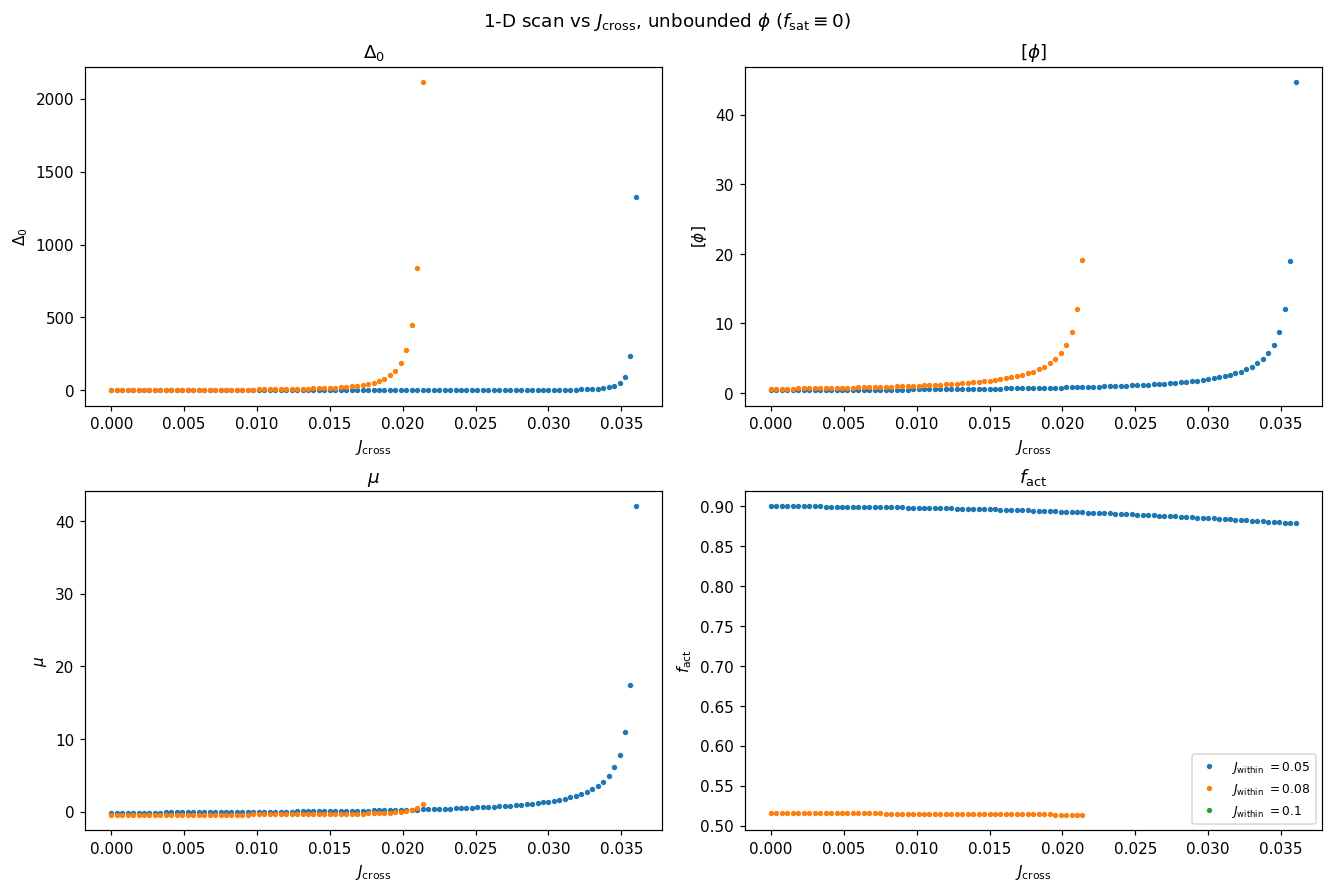

In [5]:
# ---- Section 1 plotting helper (shared) ----
STAT_LABELS = {'D0': r'$\Delta_0$', 'rate': r'$[\phi]$', 'mu': r'$\mu$',
               'phi_prime': r"$\langle\phi'\rangle$", 'f_saturated': r'$f_{\rm sat}$',
               'f_active': r'$f_{\rm act}$', 'f_silent': r'$f_{\rm sil}$'}


def scan_figure(sweep_spec, curve_spec, stats, phi_max, fname, title):
    """Run scan_1d for each curve value and plot the requested observables (one axes each)."""
    ncols = 2; nrows = int(np.ceil(len(stats) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False,
                             constrained_layout=True)
    axf = axes.ravel()
    for cval in curve_spec['values']:
        res = scan_1d(sweep_spec['values'], sweep_spec['updates'],
                      base_updates=curve_spec['updates'](cval), phi_max=phi_max)
        lbl = fr"{curve_spec['label']} $={cval:g}$"
        for ax, st in zip(axf, stats):
            ax.plot(sweep_spec['values'], res[st], 'o', ms=2.5, label=lbl)
    for ax, st in zip(axf, stats):
        ax.set_xlabel(sweep_spec['label']); ax.set_ylabel(STAT_LABELS.get(st, st))
        ax.set_title(STAT_LABELS.get(st, st))
    axf[len(stats) - 1].legend(fontsize=8)
    for ax in axf[len(stats):]:
        ax.set_visible(False)
    fig.suptitle(title)
    fig.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()


sweep_Jc = dict(label=r'$J_{\rm cross}$', values=np.linspace(0.0, 0.06, 161),
                updates=lambda v: {"J_cross[0,1]": v, "J_cross[1,0]": v})
curve_Jw = dict(label=r'$J_{\rm within}$', values=[0.05, 0.08, 0.10],
                updates=lambda c: {"areas[0].J_exc": c, "areas[1].J_exc": c})

# unbounded: no saturation possible (f_sat == 0), so we show the activated fraction f_act
scan_figure(sweep_Jc, curve_Jw, ['D0', 'rate', 'mu', 'f_active'], np.inf,
            "DMFT_catastrophe_1d_unbounded.png",
            r"1-D scan vs $J_{\rm cross}$, unbounded $\phi$ ($f_{\rm sat}\equiv0$)")

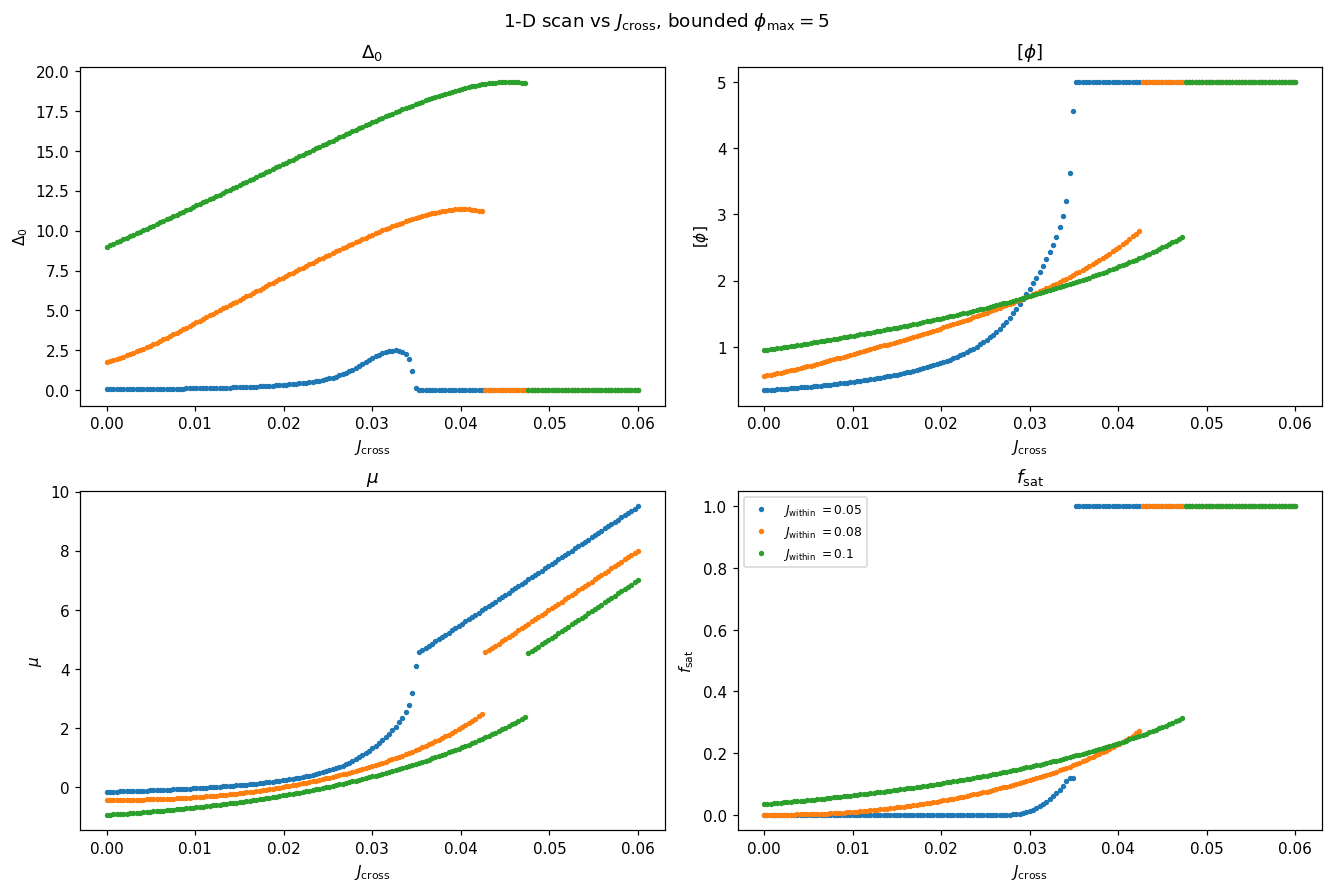

In [6]:
# bounded phi_max = 5: the saturated fraction f_sat is now non-trivial
scan_figure(sweep_Jc, curve_Jw, ['D0', 'rate', 'mu', 'f_saturated'], 5.0,
            "DMFT_catastrophe_1d_bounded.png",
            r"1-D scan vs $J_{\rm cross}$, bounded $\phi_{\max}=5$")

### The $\phi'=0$ mass resolved: silent vs saturated

Stacking the three fractions along the $J_{\rm within}=0.10$ cut shows the catastrophe **as a
saturation transition**: the chaotic state is roughly half silent / half active with only a
small saturated tail, until at the fold the population snaps almost entirely into the
**saturated** band ($f_{\rm sat}\to1$) -- the bounded activation clips the runaway
cross-excitation, the variance collapses, and chaos dies.

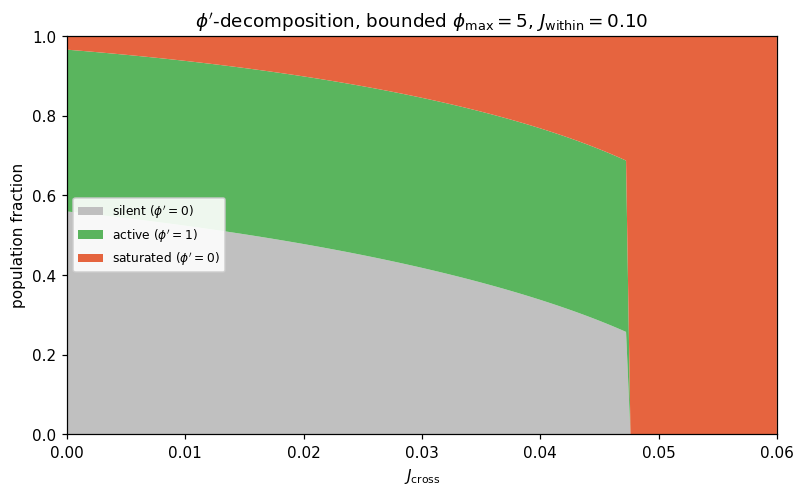

In [7]:
# stacked silent / active / saturated along the J_within = 0.10 catastrophe cut
xs = np.linspace(0.0, 0.06, 161)
res = scan_1d(xs, lambda v: {"J_cross[0,1]": v, "J_cross[1,0]": v},
              base_updates={"areas[0].J_exc": 0.10, "areas[1].J_exc": 0.10}, phi_max=5.0)

# fractions must partition the population
assert np.allclose(res['f_silent'] + res['f_active'] + res['f_saturated'], 1.0, atol=1e-9)

fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
ax.stackplot(xs, res['f_silent'], res['f_active'], res['f_saturated'],
             labels=[r"silent ($\phi'=0$)", r"active ($\phi'=1$)",
                     r"saturated ($\phi'=0$)"],
             colors=['#BBBBBB', '#4CAF50', '#E4572E'], alpha=0.92)
ax.set_xlim(0, 0.06); ax.set_ylim(0, 1)
ax.set_xlabel(r'$J_{\rm cross}$'); ax.set_ylabel('population fraction')
ax.set_title(r"$\phi'$-decomposition, bounded $\phi_{\max}=5$, $J_{\rm within}=0.10$")
ax.legend(loc='center left', fontsize=8, framealpha=0.9)
fig.savefig("DMFT_catastrophe_phiprime_Jwithin.png", dpi=200, bbox_inches="tight")
plt.show()

## 2. Nullcline analysis (2018 Fig. S1-G)

Both areas are identical, so on the symmetric subspace ($\mu_0=\mu_1$, $\Delta_0^0=\Delta_0^1$)
the two-area DMFT collapses to a single population whose effective couplings are the **row sums**
of the effective matrices, giving the population-averaged equations (2018 Eq. 83)

$$\mu=F(\mu,\Delta_0)=\Lambda_{\rm eff}\langle\phi\rangle+I,\qquad
  \Delta_0=G(\mu,\Delta_0)=\sqrt{2\,\Sigma_{\rm eff}\,Q(\mu,\Delta_0)}.$$

The $\mu$-nullcline (grey, $\mu=F$) and $\Delta_0$-nullcline (orange, $\Delta_0=G$) are traced
by root-solving one equation over a grid of the other variable; their intersections are the
self-consistent solutions, marked **filled = stable / open = unstable** by the spectral radius
of the reduced $2\times2$ fixed-point Jacobian (the outlier-eigenvalue stability of Fig. S1-G).
Sweeping $J_{\rm cross}$ across the fold, the intersections go $2\to3\to1$: the fold catastrophe
seen graphically. The small side panels show how each nullcline is built from its map.

### Derivation of the variance self-consistency $\Delta_0=\sqrt{2\,\Sigma_{\rm eff}Q}$

The $\Delta_0$-map is not an assumption — it is the **energy-conservation** result of the DMFT
correlation dynamics. Let $\Delta(\tau)=\langle\delta x(t)\,\delta x(t+\tau)\rangle$ be the
connected autocorrelation of the fluctuating input, with $\Delta(0)=\Delta_0$. In the DMFT the
single-site input is Gaussian and its autocorrelation obeys the second-order ("Newtonian")
equation of motion (same $\ddot{\vec\Delta}=\vec\Delta-M_{\rm random}\vec q$ as the sampled
autocorrelation, here on the symmetric subspace):

$$\ddot\Delta(\tau)=\Delta(\tau)-\Sigma_{\rm eff}\,q\big(\Delta(\tau),\Delta_0\big),\qquad
  q(\Delta,\Delta_0)=C(\Delta,\Delta_0)-\langle\phi\rangle^2,\qquad
  C(\Delta,\Delta_0)=\big\langle\!\big\langle \phi(x)\,\phi(y)\big\rangle\!\big\rangle,$$

where $(x,y)$ are jointly Gaussian with mean $\mu$, variance $\Delta_0$ and covariance $\Delta$.

**1. First integral (energy).** Reading $\Delta$ as the position of a particle in fictitious
time $\tau$, the "force" $\Delta-\Sigma_{\rm eff}q=-V'(\Delta)$ derives from a potential, so
$E=\tfrac12\dot\Delta^2-V(\Delta)$ is conserved, with
$V(\Delta)=\tfrac12\Delta^2-\Sigma_{\rm eff}\!\int_0^\Delta q\,d\Delta'.$

**2. Integrate $q$ with Price's theorem.** Because $\phi=P'$ (the primitive $P(x)=\int^x\phi$),
Gaussian integration by parts gives
$\partial_\Delta\langle\!\langle P(x)P(y)\rangle\!\rangle=\langle\!\langle \phi(x)\phi(y)\rangle\!\rangle=C$, hence

$$\int_0^\Delta q\,d\Delta'
   =\big[\langle\!\langle P(x)P(y)\rangle\!\rangle(\Delta)-\langle P\rangle^2\big]-\langle\phi\rangle^2\,\Delta .$$

**3. Boundary conditions.** A symmetric autocorrelation peaks at $\tau=0$, so $\dot\Delta(0)=0$
at $\Delta(0)=\Delta_0$; a fully decorrelating (chaotic) solution has $\Delta(\infty)=0$,
$\dot\Delta(\infty)=0$. At $\tau\to\infty$ the two copies are independent,
$\langle\!\langle PP\rangle\!\rangle(0)=\langle P\rangle^2$, so evaluating $E$ there gives
$E=0$.

**4. Evaluate at $\tau=0$.** There $x=y$ (covariance $=$ variance $=\Delta_0$), so
$\langle\!\langle PP\rangle\!\rangle(\Delta_0,\Delta_0)=\langle P^2\rangle$, and $E=0$ reads

$$\tfrac12\Delta_0^2=\Sigma_{\rm eff}\big(\langle P^2\rangle-\langle P\rangle^2-\Delta_0\langle\phi\rangle^2\big)
   \equiv \Sigma_{\rm eff}\,Q
   \;\;\Longrightarrow\;\;
   \boxed{\;\Delta_0=\sqrt{2\,\Sigma_{\rm eff}\,Q}\;},\quad
   Q=\langle P^2\rangle-\langle P\rangle^2-\Delta_0\langle\phi\rangle^2 .$$

This is exactly `G_map` (with `Q_diag` $=Q$). It assumes the fully-decaying ($\Delta_\infty=0$)
chaotic branch; a nonzero plateau $\Delta_\infty$ needs the landing-condition treatment. It
reduces to Pan2's single-population formula, with $\Sigma_{\rm eff}$ the row sum of
$M_{\rm random}$ for the symmetric two-area network.

In [5]:
from scipy.optimize import brentq

# ======================================================================================
# Section 2 -- Nullcline analysis (symmetric-subspace reduction, 2018 Eq. 83 / Fig. S1-G)
# ======================================================================================
# Both areas are identical, so on the symmetric subspace (mu_0=mu_1=mu, D0_0=D0_1=D0) the
# two-area DMFT collapses to a single population whose effective couplings are the ROW SUMS
# of the effective matrices (verified in the solver cell). The stationary equations are then
#     mu = F(mu, D0) = Lam_eff <phi>(mu,D0) + I ,
#     D0 = G(mu, D0) = sqrt( 2 Sig_eff Q(mu,D0) ) .
# The two nullclines are the loci where each equation holds; their intersections are the
# self-consistent solutions -- exactly the graphical construction of Fig. S1-G.


def effective_couplings(p):
    """Symmetric-subspace scalars (Lam_eff, Sig_eff, I) = row sums of M_structure / M_random."""
    Ms = build_M_structure(p); Mr = build_M_random(p)
    return float(Ms[0].sum()), float(Mr[0].sum()), float(p.I_ext[0])


def F_map(mu, D0, Lam, I, gamma, phi_max):
    """mu-map: mu = Lam_eff <phi>(mu,D0) + I."""
    return Lam * mean_phi(mu, D0, gamma, phi_max) + I


def G_map(mu, D0, Sig, gamma, phi_max):
    """Delta0-map: D0 = sqrt(2 Sig_eff Q(mu,D0))."""
    return math.sqrt(max(2.0 * Sig * Q_diag(mu, D0, gamma, phi_max), 0.0))


def mu_star_slaved(D0, Lam, I, gamma, phi_max, seed=0.0, eps=0.4, iters=3000, tol=1e-11):
    """Stable fixed point mu = F(mu, D0) by DAMPED iteration from `seed` (same scheme as the
    full solver). Damping -- not Newton -- because at Delta0=0 the deterministic phi has a hard
    kink at which Newton oscillates; damped iteration converges to the saturated / linear-band
    root cleanly. Warm-starting `seed` from a neighbour selects the continuous branch and makes
    the inner loop terminate in a handful of steps."""
    mu = float(seed)
    for _ in range(iters):
        mu_new = (1.0 - eps) * mu + eps * (Lam * mean_phi(mu, D0, gamma, phi_max) + I)
        if abs(mu_new - mu) < tol:
            mu = mu_new
            break
        mu = mu_new
    return mu


def _all_roots(func, lo, hi, n=250):
    """All roots of `func` on [lo, hi] via sign-change bracketing (captures multivalued
    branches, e.g. an S-shaped map near a structural / saddle-node instability)."""
    xs = np.linspace(lo, hi, n)
    fs = np.array([func(x) for x in xs])
    roots = []
    for i in range(n - 1):
        a, b = fs[i], fs[i + 1]
        if a == 0.0:
            roots.append(float(xs[i]))
        elif np.isfinite(a) and np.isfinite(b) and a * b < 0:
            try:
                roots.append(float(brentq(func, xs[i], xs[i + 1], xtol=1e-12)))
            except ValueError:
                pass
    return roots


def mu_nullcline(Lam, I, gamma, phi_max, D0_grid):
    """Points (mu, D0) with mu = F(mu, D0): for each D0 solve mu = F(mu, D0) for all mu.
    Warm-starts along the D0 grid so the traced branch stays continuous."""
    pts_mu, pts_D0 = [], []
    seed = 0.0
    for D0 in D0_grid:
        for mr in _all_roots(lambda mu: mu - F_map(mu, D0, Lam, I, gamma, phi_max), -60.0, 60.0):
            pts_mu.append(mr); pts_D0.append(float(D0)); seed = mr
    return np.array(pts_mu), np.array(pts_D0)


def D0_nullcline(Sig, gamma, phi_max, mu_grid, D0_hi=40.0):
    """Points (mu, D0) with D0 = G(mu, D0): for each mu solve D0 = G(mu, D0) for all D0>=0
    (D0=0 is always a root; a nonzero root, when present, is the chaotic branch)."""
    pts_mu, pts_D0 = [], []
    for mu in mu_grid:
        pts_mu.append(float(mu)); pts_D0.append(0.0)                      # trivial branch
        for dr in _all_roots(lambda D0: D0 - G_map(mu, D0, Sig, gamma, phi_max), 1e-6, D0_hi):
            pts_mu.append(float(mu)); pts_D0.append(dr)
    return np.array(pts_mu), np.array(pts_D0)


def _mu_profile(Lam, I, gamma, phi_max, D0_grid):
    """mu*(D0) along the CONTINUOUS branch: Newton-solve mu=F(mu,D0) sweeping D0 upward,
    warm-starting each point from the previous. Returns the mu array (same length as D0_grid)."""
    mus = np.empty(len(D0_grid))
    seed = mu_star_slaved(float(D0_grid[0]), Lam, I, gamma, phi_max, seed=0.0)
    for i, D0 in enumerate(D0_grid):
        seed = mu_star_slaved(float(D0), Lam, I, gamma, phi_max, seed=seed)
        mus[i] = seed
    return mus


def trivial_stable(Lam, Sig, I, gamma, phi_max, D0_eval=1e-4):
    """Stability of the trivial Delta0=0 solution via the LINEAR variance criterion
    rho_random = Sig_eff <phi'^2>(mu*) < 1 (the sqrt variance map linearises to this; the
    finite-difference Jacobian is singular at Delta0=0 because G ~ sqrt(Delta0))."""
    mu0 = mu_star_slaved(0.0, Lam, I, gamma, phi_max, seed=0.0)
    rho = Sig * phi_prime_sq_mean(mu0, gamma, phi_max, D0_eval)
    return mu0, rho < 1.0, rho


def reduced_jacobian_radius(mu, D0, Lam, Sig, I, gamma, phi_max, h=1e-5):
    """Spectral radius of the Jacobian of the reduced fixed-point map (mu,D0)->(F,G) at a
    NONZERO solution. rho<1 -> stable (the outlier-eigenvalue stability marked in Fig. S1-G).
    (Use `trivial_stable` for Delta0=0, where dG/dDelta0 is singular.)"""
    def Fv(m, d): return F_map(m, d, Lam, I, gamma, phi_max)
    def Gv(m, d): return G_map(m, d, Sig, gamma, phi_max)
    hd = max(h, 1e-5 * max(D0, 1.0))
    lo_d = max(D0 - hd, 0.0); span_d = (D0 + hd) - lo_d
    dFdm = (Fv(mu + h, D0) - Fv(mu - h, D0)) / (2 * h)
    dFdd = (Fv(mu, D0 + hd) - Fv(mu, lo_d)) / span_d
    dGdm = (Gv(mu + h, D0) - Gv(mu - h, D0)) / (2 * h)
    dGdd = (Gv(mu, D0 + hd) - Gv(mu, lo_d)) / span_d
    J = np.array([[dFdm, dFdd], [dGdm, dGdd]])
    return float(np.max(np.abs(np.linalg.eigvals(J))))


def stationary_solutions(Lam, Sig, I, gamma, phi_max, D0_hi=40.0, n=400):
    """Self-consistent (mu, D0) solutions = nullcline intersections, each tagged stable/unstable.
    mu is slaved along the continuous branch (stateless interpolant, so root-finding cannot
    corrupt the warm-start); the trivial D0=0 solution uses the linear criterion, nonzero ones
    the reduced Jacobian. Returns list of (mu, D0, is_stable, rho)."""
    D0g = np.linspace(0.0, D0_hi, n)
    mus = _mu_profile(Lam, I, gamma, phi_max, D0g)
    muf = lambda D0: float(np.interp(D0, D0g, mus))

    def H(D0):
        return G_map(muf(D0), D0, Sig, gamma, phi_max) - D0

    mu0, triv_stab, rho0 = trivial_stable(Lam, Sig, I, gamma, phi_max)
    out = [(mu0, 0.0, triv_stab, rho0)]
    for D0 in _all_roots(H, 1e-6, D0_hi, n=n):
        mu = muf(D0)
        rho = reduced_jacobian_radius(mu, D0, Lam, Sig, I, gamma, phi_max)
        out.append((mu, D0, rho < 1.0, rho))
    return out

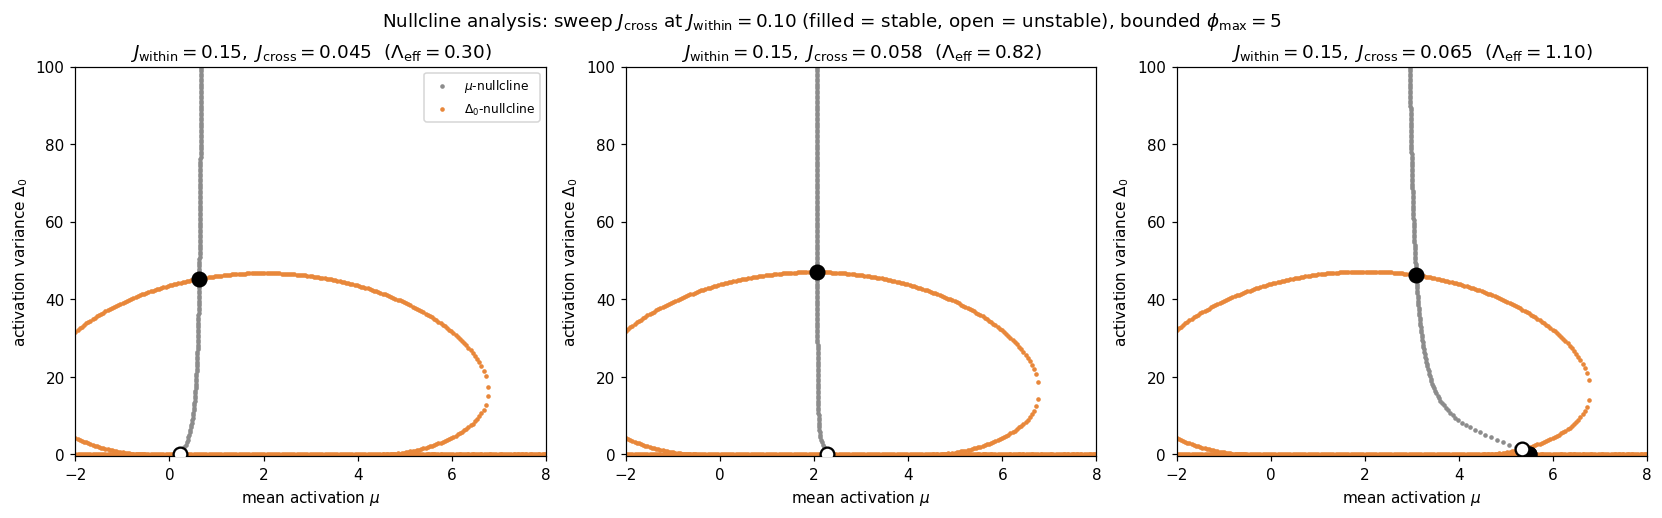

In [14]:
# ---- nullcline plots at three J_cross values spanning the fold ----
def nullcline_panel(ax, Jw, Jc, D0_max=100):
    """(mu, Delta_0)-plane nullclines + tagged intersections for one (J_within, J_cross)."""
    p = apply_updates_to_params(base_p, {"areas[0].J_exc": Jw, "areas[1].J_exc": Jw,
                                         "J_cross[0,1]": Jc, "J_cross[1,0]": Jc, "phi_max": 5.0})
    Lam, Sig, I = effective_couplings(p); gam, pm = p.gamma, p.phi_max
    mm, md = mu_nullcline(Lam, I, gam, pm, np.linspace(0.0, D0_max, 160))
    dm, dd = D0_nullcline(Sig, gam, pm, np.linspace(-2.0, 8.0, 220), D0_hi=D0_max)
    ax.scatter(mm, md, s=4, color='0.55', label=r'$\mu$-nullcline')
    ax.scatter(dm, dd, s=4, color='#E8873A', label=r'$\Delta_0$-nullcline')
    for mu, D0, st, rho in stationary_solutions(Lam, Sig, I, gam, pm, D0_hi=D0_max):
        ax.plot(mu, D0, 'o', ms=9, mfc=('k' if st else 'white'), mec='k', mew=1.5, zorder=5)
    ax.set_xlim(-2, 8); ax.set_ylim(-0.5, D0_max)
    ax.set_xlabel(r'mean activation $\mu$'); ax.set_ylabel(r'activation variance $\Delta_0$')
    ax.set_title(fr'$J_{{\rm within}}={Jw:g},\ J_{{\rm cross}}={Jc:g}$  ($\Lambda_{{\rm eff}}={Lam:.2f}$)')


fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
for ax, Jc in zip(axes, [0.045, 0.058, 0.065]):
    nullcline_panel(ax, 0.15, Jc)
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle(r'Nullcline analysis: sweep $J_{\rm cross}$ at $J_{\rm within}=0.10$ '
             r'(filled = stable, open = unstable), bounded $\phi_{\max}=5$')
fig.savefig("DMFT_catastrophe_nullclines.png", dpi=200, bbox_inches="tight")
plt.show()

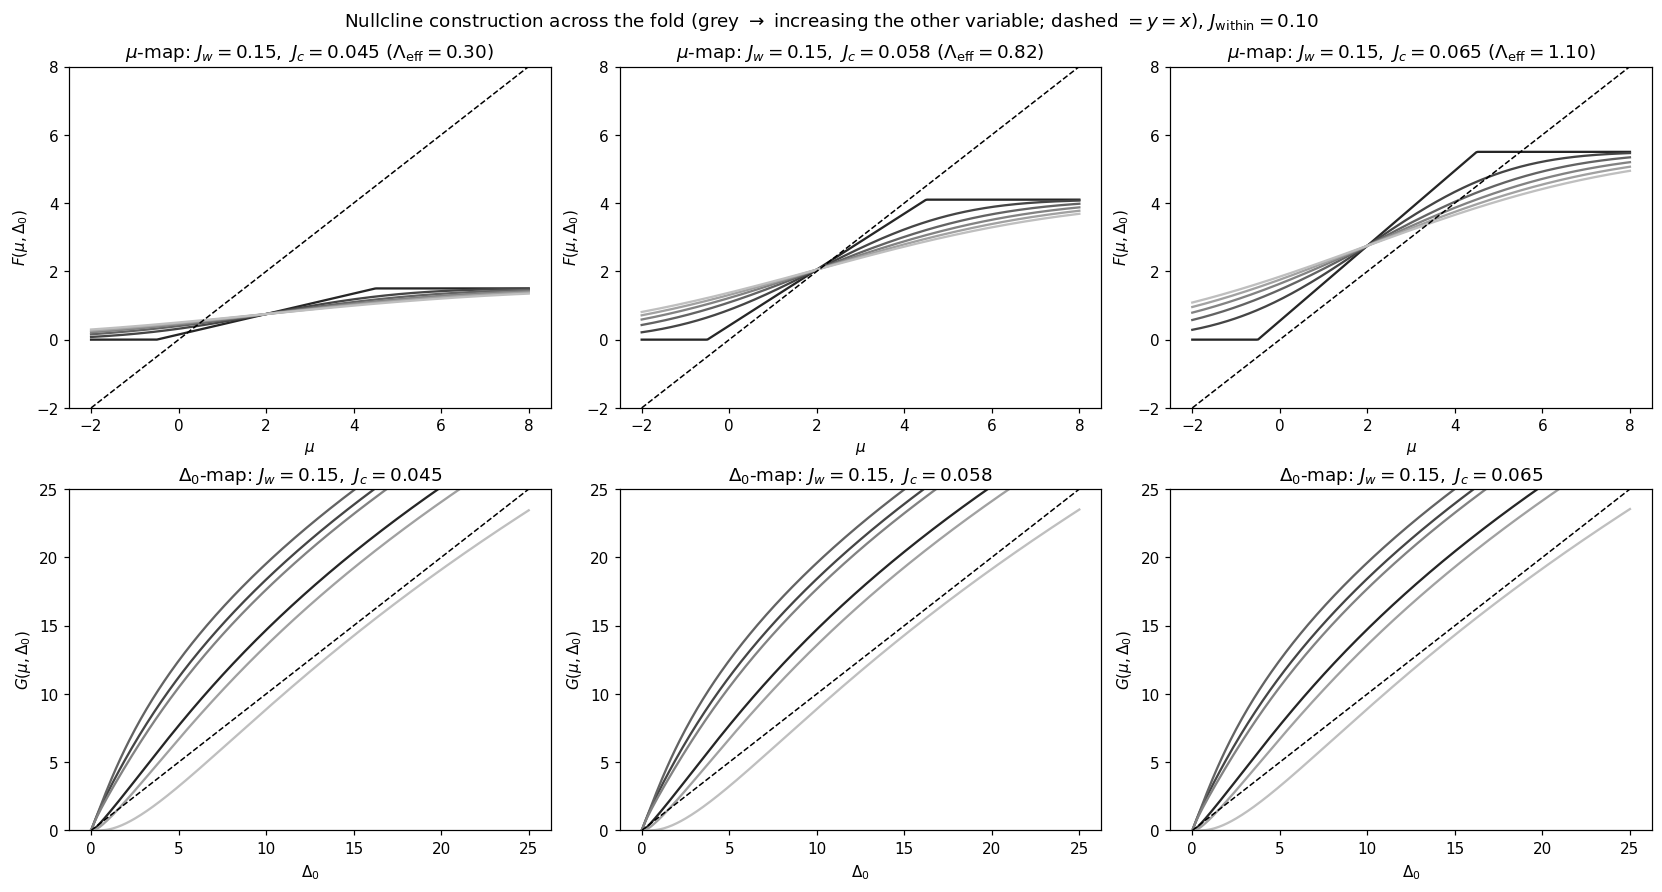

In [13]:
# ---- how each nullcline is built: the F(mu) and G(D0) maps with the y=x diagonal ----
def construction_col(axF, axG, Jw, Jc, phi_max=5.0):
    """One (J_within, J_cross) column of the construction: the mu-map F(mu,Delta_0) (grey =
    increasing Delta_0) and the Delta_0-map G(mu,Delta_0) (grey = increasing mu), each with its
    y=x diagonal. Crossings of a curve with the diagonal are the roots that build the nullcline."""
    p = apply_updates_to_params(base_p, {"areas[0].J_exc": Jw, "areas[1].J_exc": Jw,
                                         "J_cross[0,1]": Jc, "J_cross[1,0]": Jc, "phi_max": phi_max})
    Lam, Sig, I = effective_couplings(p); gam, pm = p.gamma, p.phi_max
    mug = np.linspace(-2, 8, 300); d0g = np.linspace(0, 25, 300)
    for D0 in np.linspace(0, 20, 6):
        axF.plot(mug, [F_map(m, D0, Lam, I, gam, pm) for m in mug], color=str(0.15 + 0.6 * D0 / 20))
    axF.plot(mug, mug, 'k--', lw=1); axF.set_xlabel(r'$\mu$'); axF.set_ylabel(r'$F(\mu,\Delta_0)$')
    axF.set_ylim(-2, 8); axF.set_title(fr'$\mu$-map: $J_w={Jw:g},\ J_c={Jc:g}$ ($\Lambda_{{\rm eff}}={Lam:.2f}$)')
    for mu in np.linspace(-1, 7, 6):
        axG.plot(d0g, [G_map(mu, d, Sig, gam, pm) for d in d0g], color=str(0.15 + 0.6 * (mu + 1) / 8))
    axG.plot(d0g, d0g, 'k--', lw=1); axG.set_xlabel(r'$\Delta_0$'); axG.set_ylabel(r'$G(\mu,\Delta_0)$')
    axG.set_ylim(0, 25); axG.set_title(fr'$\Delta_0$-map: $J_w={Jw:g},\ J_c={Jc:g}$')


JC_LIST = [0.045, 0.058, 0.065]
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for k, Jc in enumerate(JC_LIST):
    construction_col(axes[0, k], axes[1, k], 0.15, Jc)
fig.suptitle(r'Nullcline construction across the fold (grey $\to$ increasing the other variable; '
             r'dashed $=y=x$), $J_{\rm within}=0.10$')
fig.savefig("DMFT_catastrophe_construction_Jcross.png", dpi=200, bbox_inches="tight")
plt.show()

## 3. Full catastrophe picture: the unstable branch via time-reversed dynamics

The forward DMFT relaxation reaches only the two **stable** branches -- the chaotic
($\Delta_0$ large) and the saturated ($\Delta_0=0$, all neurons clipped). We trace them with
warm-started continuation (forward low-seed / backward high-seed, reusing `continuation_sweep`).

The **unstable middle branch** is a repeller of the $\Delta_0$ relaxation, so we recover it by
**reversing time on the slow $\Delta_0$ variable while slaving the fast, stable $\mu$**:

$$\mu^\star=\text{fixed point of }\mu=F(\mu,\Delta_0),\qquad
  \frac{d\Delta_0}{dt}=\Delta_0-G(\mu^\star,\Delta_0)\;\;(\textbf{reversed sign}).$$

(Reversing the *full* 2-D flow would leave the saddle a saddle; slaving $\mu$ and reversing only
$\Delta_0$ turns the middle branch into a clean attractor of the reversed flow -- the idea used
for the dashed unstable solutions in `2018main_mf.py`.) A bracketed root of $G(\mu^\star,\Delta_0)-\Delta_0$
cross-checks every recovered point. Overlaying the unstable branch (dashed) on the two stable
branches completes the subcritical / fold $S$-curve.

In [7]:
# ======================================================================================
# Section 3 -- Full catastrophe picture: unstable branch via TIME-REVERSED dynamics
# ======================================================================================
# The forward DMFT relaxation converges only to the two STABLE branches. The unstable middle
# branch is a repeller of the Delta0 relaxation, so we RECOVER it by reversing time on the slow
# Delta0 variable while slaving the fast, stable mu:
#     mu*    = fixed point of  mu = F(mu, D0)         (damped iteration -> attracting)
#     dD0/dt = D0 - G(mu*, D0)                        (reversed sign -> repeller becomes attractor)
# (Reversing the full 2-D flow would leave the saddle a saddle; slaving mu and reversing only
#  Delta0 makes the middle branch a clean attractor of the reversed flow.) A bracketed brentq
# root of G(mu*,D0)-D0 cross-checks every recovered point.


def unstable_D0_reversed(Lam, Sig, I, gamma, phi_max, D0_seed, mu_seed=0.0,
                         dt=0.05, n_steps=6000, D0_cap=60.0, tol=1e-9):
    """Time-reversed Delta0 flow (mu slaved) -> unstable Delta0 fixed point."""
    D0 = float(D0_seed); mu = float(mu_seed)
    for _ in range(n_steps):
        mu = mu_star_slaved(D0, Lam, I, gamma, phi_max, seed=mu, iters=25)
        drift = D0 - G_map(mu, D0, Sig, gamma, phi_max)   # reversed relaxation
        D0_new = min(max(D0 + dt * drift, 1e-8), D0_cap)
        if abs(D0_new - D0) < tol:
            D0 = D0_new; break
        D0 = D0_new
    return D0, mu


def unstable_D0_bracketed(Lam, Sig, I, gamma, phi_max, lo, hi, n=200):
    """Middle Delta0 root of H(D0)=G(mu*(D0),D0)-D0 on [lo,hi] via a stateless mu*(D0)
    interpolant (cross-check for the time-reversed result)."""
    D0g = np.linspace(lo, hi, n)
    mus = _mu_profile(Lam, I, gamma, phi_max, D0g)
    muf = lambda D0: float(np.interp(D0, D0g, mus))
    H = lambda D0: G_map(muf(D0), D0, Sig, gamma, phi_max) - D0
    Hlo, Hhi = H(lo), H(hi)
    if not (np.isfinite(Hlo) and np.isfinite(Hhi)) or Hlo * Hhi > 0:
        return np.nan
    return float(brentq(H, lo, hi, xtol=1e-10))


# ---- stable-branch machinery (reused from the catastrophe cells; full 2-area solver) ----

def solve_branch_point(p, mu0, D0_0):
    """Solve the DMFT from a GIVEN initial guess (mu0, D0_0), with NO linear-onset gating.
    Returns converged area-0 observables; NaN if diverged."""
    sol = solve_selfconsistent(p, mu0=np.array(mu0, float), D0_0=np.array(D0_0, float))
    if sol['diverged']:
        return dict(D0=np.nan, rate=np.nan, mu=np.nan, phi_prime=np.nan,
                    f_saturated=np.nan, diverged=True)
    d0, m = float(sol['Delta0'][0]), float(sol['mu'][0])
    fs, fa, fsat = phi_prime_fractions(m, d0, p.gamma, p.phi_max)
    return dict(D0=d0, rate=float(sol['rate'][0]), mu=m, phi_prime=fa,
                f_saturated=fsat, diverged=False)


def continuation_sweep(x_values, x_updates, base_updates, phi_max, mu0, D0_0):
    """Warm-start continuation: solve along x_values IN ORDER, seeding each point from the
    previous converged (mu, Delta0). A tiny Delta0 floor avoids the exact-0 solver trap so a
    low branch can still jump up at a fold. Returns 1-D arrays keyed by stat, including the full
    phi'-fraction split (f_silent / f_active / f_saturated)."""
    base_updates = dict(base_updates or {})
    stats = ('D0', 'rate', 'mu', 'phi_prime', 'f_silent', 'f_active', 'f_saturated')
    out = {s: np.full(len(x_values), np.nan) for s in stats}
    mu, D0 = np.array(mu0, float), np.array(D0_0, float)
    for i, xv in enumerate(x_values):
        p = apply_updates_to_params(base_p, {**base_updates, **x_updates(float(xv)),
                                             "phi_max": phi_max})
        sol = solve_selfconsistent(p, mu0=mu, D0_0=D0)
        if sol['diverged']:
            continue
        mu = sol['mu'].copy()
        D0 = np.maximum(sol['Delta0'].copy(), 1e-6)
        m, d0 = sol['mu'][0], sol['Delta0'][0]
        fsil, fact, fsat = phi_prime_fractions(m, d0, p.gamma, p.phi_max)
        out['D0'][i] = d0; out['rate'][i] = sol['rate'][0]; out['mu'][i] = m
        out['phi_prime'][i] = fact
        out['f_silent'][i] = fsil; out['f_active'][i] = fact; out['f_saturated'][i] = fsat
    return out


# ---- full catastrophe picture for ANY 1-parameter sweep (reused by Sec. 3 and Sec. 4) ----
_CAT_PANELS = [('D0', r'$\Delta_0$', r'variance $\Delta_0$'),
               ('rate', r'$[\phi]$', r'mean rate $[\phi]$'),
               ('mu', r'$\mu$', r'mean input $\mu$'),
               ('f_saturated', r'$f_{\rm sat}$', r'saturated fraction ($\phi=\phi_{\max}$)'),
               ('f_active', r'$f_{\rm act}$', r"active fraction ($\phi'=1$)"),
               ('f_silent', r'$f_{\rm sil}$', r'silent fraction ($\phi=0$)')]


def catastrophe_analysis(sweep, base_updates, xvals, xlabel, title, fname,
                         phi_max=5.0, n_unstable=60):
    """Trace the two stable branches (forward/backward continuation), pick the higher-Delta0
    (chaotic) and lower (saturated) branch ELEMENTWISE so the routine is orientation-agnostic,
    recover the unstable middle branch by time-reversed dynamics (cross-checked with a bracketed
    root), and draw the 3x2 figure of Delta0, [phi], mu, f_sat, f_act, f_sil. Returns the arrays."""
    xvals = np.asarray(xvals, float)
    p0 = apply_updates_to_params(base_p, {**base_updates, **sweep(float(xvals[0])), "phi_max": phi_max})
    fwd = continuation_sweep(xvals, sweep, base_updates, phi_max, fixed_point_mu(p0), [1e-3, 1e-3])
    bwd_r = continuation_sweep(xvals[::-1], sweep, base_updates, phi_max, [10., 10.], [8., 8.])
    bwd = {s: bwd_r[s][::-1] for s in bwd_r}

    fh = np.nan_to_num(fwd['D0'], nan=-1.0); bh = np.nan_to_num(bwd['D0'], nan=-1.0)
    use_fwd = fh >= bh
    hi = {k: np.where(use_fwd, fwd[k], bwd[k]) for k in fwd}     # higher-Delta0 (chaotic) branch
    lo = {k: np.where(use_fwd, bwd[k], fwd[k]) for k in fwd}     # lower-Delta0 (saturated) branch
    thr = 1e-2
    cha_mask = hi['D0'] > thr
    sat_mask = np.nan_to_num(lo['D0'], nan=1e9) < thr
    window = cha_mask & sat_mask & (hi['D0'] - np.nan_to_num(lo['D0'], nan=1e9) > thr)
    Jlo = xvals[window].min() if window.any() else np.nan
    Jhi = xvals[window].max() if window.any() else np.nan

    xu = np.linspace(Jlo, Jhi, n_unstable) if window.any() else np.array([])
    U = {k: np.full(len(xu), np.nan) for k in ('D0', 'rate', 'mu', 'f_silent', 'f_active', 'f_saturated')}
    Ub = np.full(len(xu), np.nan)
    for i, xv in enumerate(xu):
        p = apply_updates_to_params(base_p, {**base_updates, **sweep(float(xv)), "phi_max": phi_max})
        Lam, Sig, I = effective_couplings(p)
        hival = hi['D0'][int(np.argmin(np.abs(xvals - xv)))]
        if not np.isfinite(hival) or hival < 0.5:
            continue
        d, mu = unstable_D0_reversed(Lam, Sig, I, p.gamma, p.phi_max, D0_seed=0.5 * hival)
        if 1e-3 < d < 0.99 * hival:
            fsil, fact, fsat = phi_prime_fractions(mu, d, p.gamma, p.phi_max)
            U['D0'][i] = d; U['rate'][i] = mean_phi(mu, d, p.gamma, p.phi_max); U['mu'][i] = mu
            U['f_silent'][i] = fsil; U['f_active'][i] = fact; U['f_saturated'][i] = fsat
        Ub[i] = unstable_D0_bracketed(Lam, Sig, I, p.gamma, p.phi_max, 0.005, 0.99 * hival)

    err = np.nanmax(np.abs(U['D0'] - Ub)) if len(xu) else np.nan
    print("fold / bistable window in [%.4f, %.4f];  "
          "unstable branch max |time-reversed - bracketed root| = %.2e" % (Jlo, Jhi, err))

    fig, axes = plt.subplots(3, 2, figsize=(13, 12.5), constrained_layout=True)
    for ax, (key, ylab, ttl) in zip(axes.ravel(), _CAT_PANELS):
        ax.plot(xvals[cha_mask], hi[key][cha_mask], '-', color='#C00000', lw=2.5, label='stable: chaotic')
        ax.plot(xvals[sat_mask], lo[key][sat_mask], '-', color='#4472C4', lw=2.5, label='stable: saturated')
        ax.plot(xu, U[key], '--', color='k', lw=2.0, label='unstable (time-reversed)')
        for Jf in (Jlo, Jhi):
            ax.axvline(Jf, color='0.7', ls=':', lw=1)
        ax.set_xlabel(xlabel); ax.set_ylabel(ylab); ax.set_title(ttl)
    axes[0, 0].legend(fontsize=8)
    fig.suptitle(title + fr'  (fold window $[{Jlo:.4f},\ {Jhi:.4f}]$)')
    fig.savefig(fname, dpi=200, bbox_inches="tight")
    plt.show()
    return dict(xvals=xvals, hi=hi, lo=lo, cha_mask=cha_mask, sat_mask=sat_mask,
                xu=xu, U=U, window=(Jlo, Jhi))

fold / bistable window in [0.0630, 0.0825];  unstable branch max |time-reversed - bracketed root| = 7.33e-03


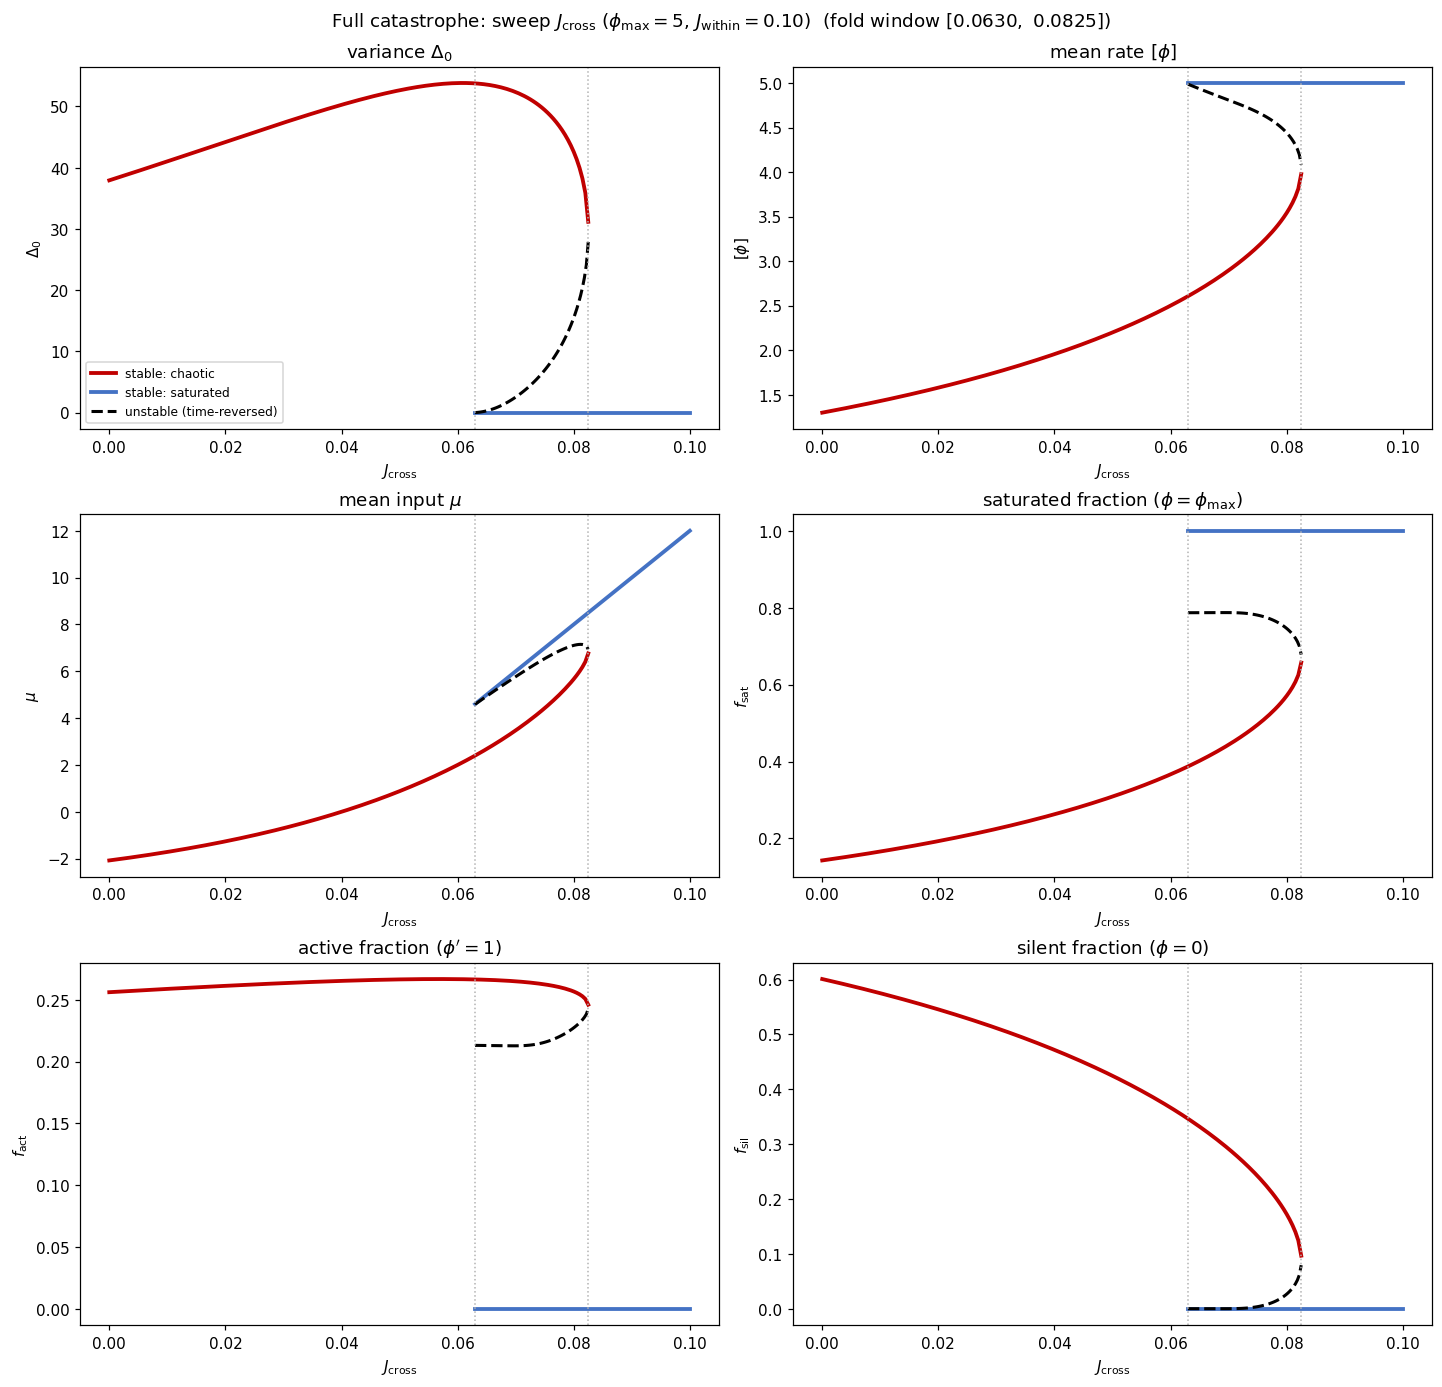

In [16]:
# Section 3: sweep J_cross at fixed J_within = 0.10 -- the chaotic state is DESTROYED as the
# cross-coupling grows (saturation collapses the variance). All six observables show the two
# stable branches (chaotic / saturated) plus the dashed unstable branch that closes the S-curve.
res_Jcross = catastrophe_analysis(
    sweep=lambda v: {"J_cross[0,1]": v, "J_cross[1,0]": v},
    base_updates={"areas[0].J_exc": 0.16, "areas[1].J_exc": 0.16},
    xvals=np.linspace(0.0, 0.10, 201),
    xlabel=r'$J_{\rm cross}$',
    title=r'Full catastrophe: sweep $J_{\rm cross}$ ($\phi_{\max}=5$, $J_{\rm within}=0.10$)',
    fname="DMFT_catastrophe_full_picture.png")

## 4. Complementary sweep: fix $J_{\rm cross}$, vary $J_{\rm within}$

The same analysis with the roles swapped: fix $J_{\rm cross}=0.05$ and sweep the within-area
coupling $J_{\rm within}$. This produces the **mirror image** of the Section-3 fold. Increasing
$J_{\rm within}$ raises the variance coupling $\Sigma_{\rm eff}\propto J_{\rm within}^2$ faster
than the mean coupling $\Lambda_{\rm eff}\propto J_{\rm within}$, so here the chaotic state is
**born** (rather than destroyed) as the coupling grows: at small $J_{\rm within}$ the strong
cross-drive holds the network saturated, and a chaotic branch appears through a saddle-node.
The nullcline intersections go $1\to3\to2$ across the fold (bistable window
$J_{\rm within}\in[0.087,0.109]$), the reverse of the $2\to3\to1$ pattern of Section 2.

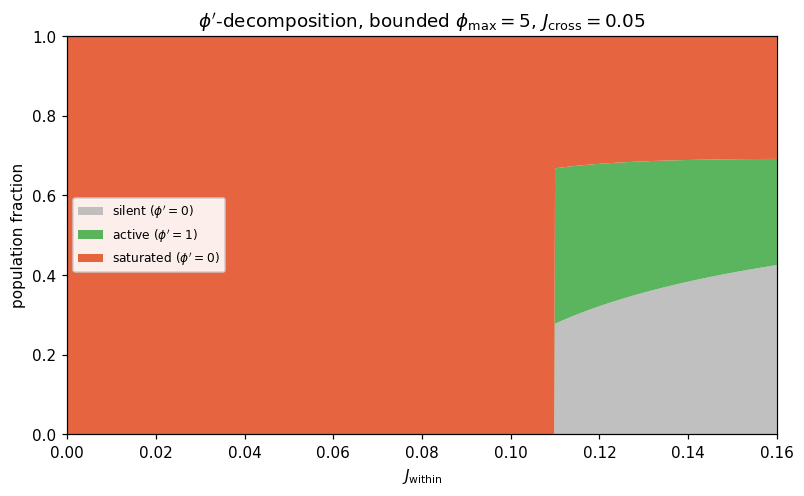

In [46]:
# stacked silent / active / saturated along the J_cross = 0.05 catastrophe cut
xs = np.linspace(0.0, 0.16, 801)
res = scan_1d(xs, lambda v: {"areas[0].J_exc": v, "areas[1].J_exc": v},
              base_updates={"J_cross[0,1]": 0.05, "J_cross[1,0]": 0.05}, phi_max=5.0)

# fractions must partition the population
assert np.allclose(res['f_silent'] + res['f_active'] + res['f_saturated'], 1.0, atol=1e-9)

fig, ax = plt.subplots(figsize=(7.2, 4.4), constrained_layout=True)
ax.stackplot(xs, res['f_silent'], res['f_active'], res['f_saturated'],
             labels=[r"silent ($\phi'=0$)", r"active ($\phi'=1$)",
                     r"saturated ($\phi'=0$)"],
             colors=['#BBBBBB', '#4CAF50', '#E4572E'], alpha=0.92)
ax.set_xlim(0, 0.16); ax.set_ylim(0, 1)
ax.set_xlabel(r'$J_{\rm within}$'); ax.set_ylabel('population fraction')
ax.set_title(r"$\phi'$-decomposition, bounded $\phi_{\max}=5$, $J_{\rm cross}=0.05$")
ax.legend(loc='center left', fontsize=8, framealpha=0.9)
fig.savefig("DMFT_catastrophe_phiprime_stack.png", dpi=200, bbox_inches="tight")
plt.show()

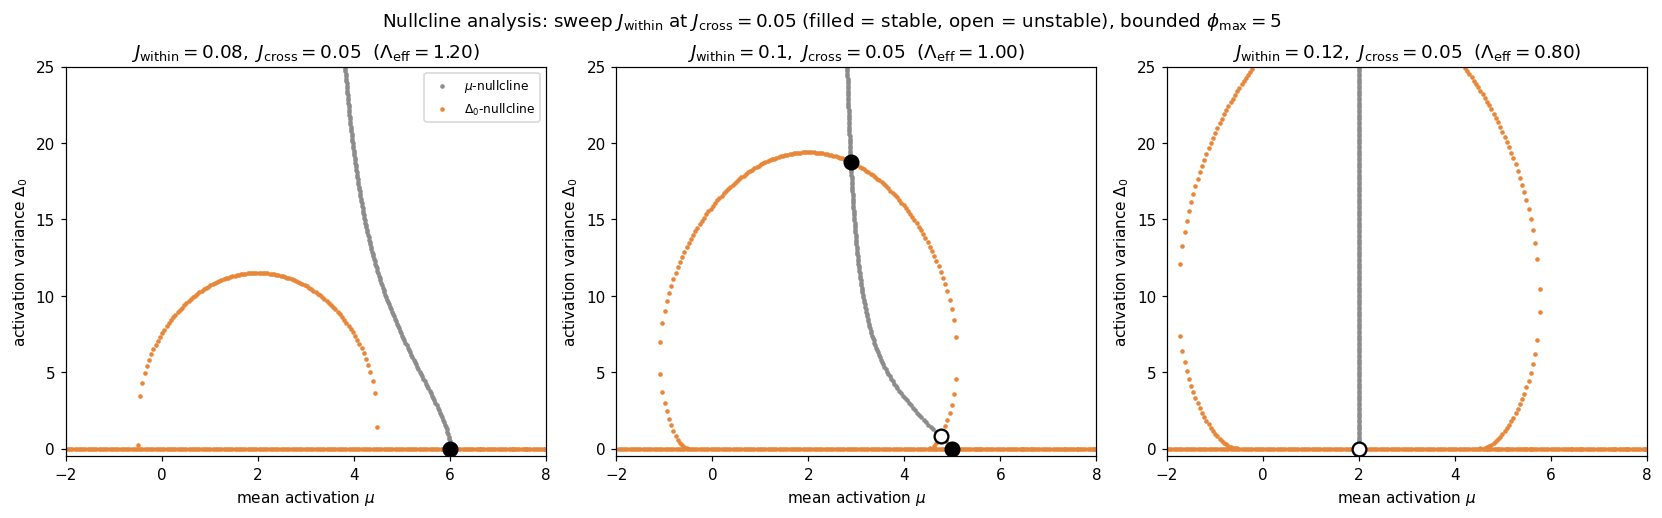

In [47]:
# ---- nullclines: fixed J_cross = 0.05, three J_within values spanning the fold ----
JC_FIX = 0.05
JW_LIST = [0.08, 0.10, 0.12]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), constrained_layout=True)
for ax, Jw in zip(axes, JW_LIST):
    nullcline_panel(ax, Jw, JC_FIX)
axes[0].legend(fontsize=8, loc='upper right')
fig.suptitle(fr'Nullcline analysis: sweep $J_{{\rm within}}$ at $J_{{\rm cross}}={JC_FIX:g}$ '
             r'(filled = stable, open = unstable), bounded $\phi_{\max}=5$')
fig.savefig("DMFT_catastrophe_nullclines_Jwithin.png", dpi=200, bbox_inches="tight")
plt.show()

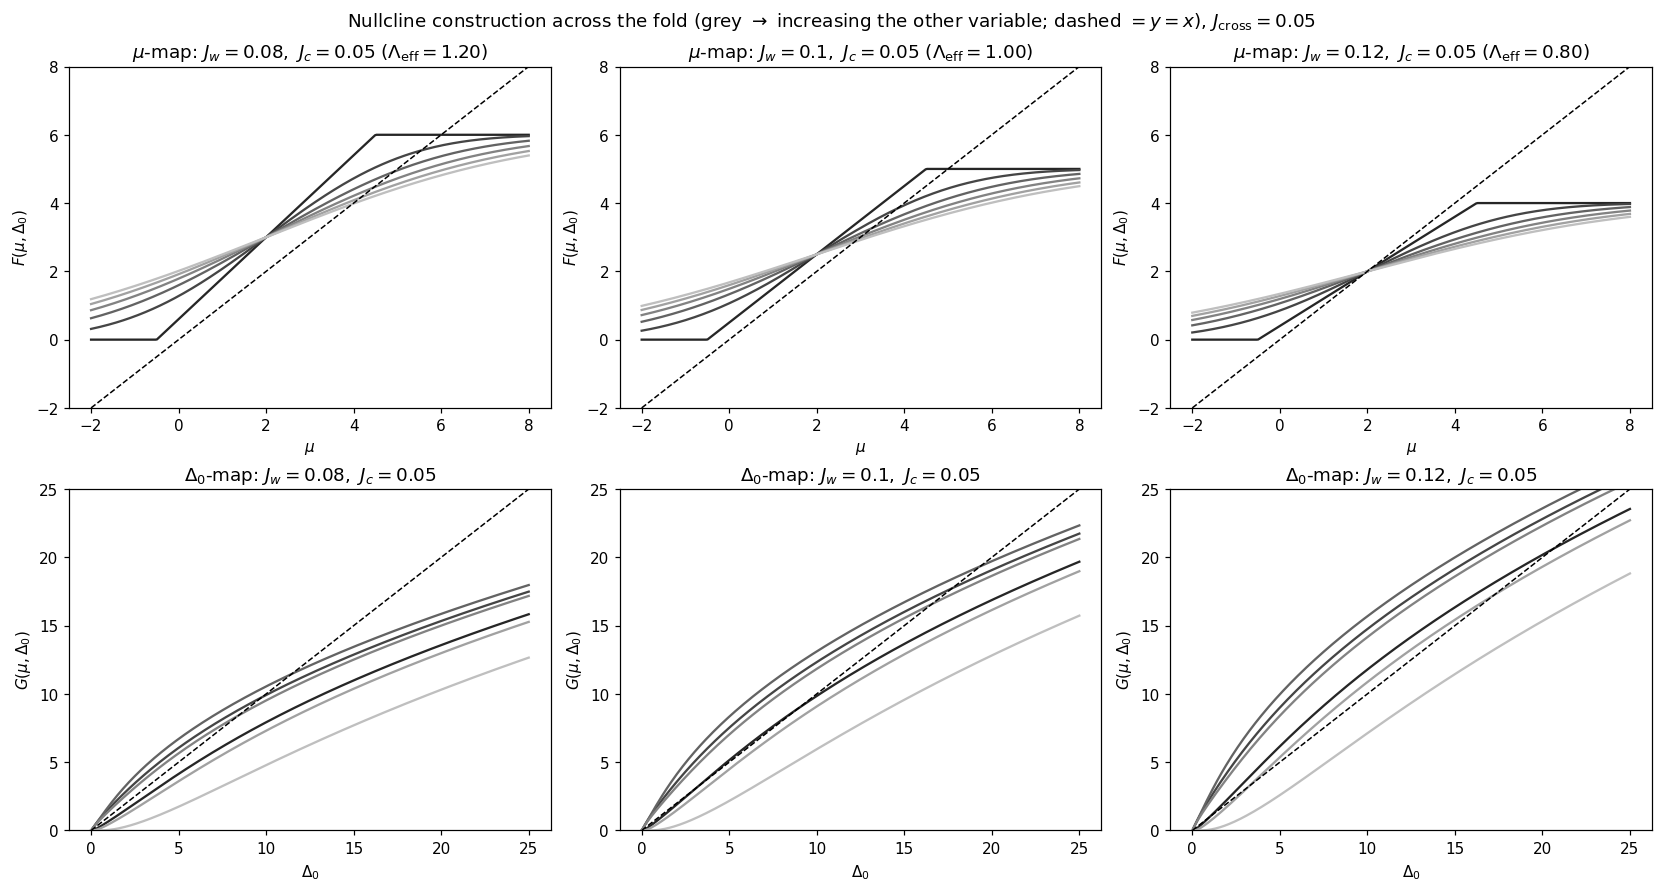

In [48]:
# ---- construction across the fold: fixed J_cross = 0.05, three J_within values ----
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
for k, Jw in enumerate(JW_LIST):
    construction_col(axes[0, k], axes[1, k], Jw, JC_FIX)
fig.suptitle(fr'Nullcline construction across the fold (grey $\to$ increasing the other variable; '
             fr'dashed $=y=x$), $J_{{\rm cross}}={JC_FIX:g}$')
fig.savefig("DMFT_catastrophe_construction_Jwithin.png", dpi=200, bbox_inches="tight")
plt.show()

fold / bistable window in [0.0870, 0.1090];  unstable branch max |time-reversed - bracketed root| = 1.78e-03


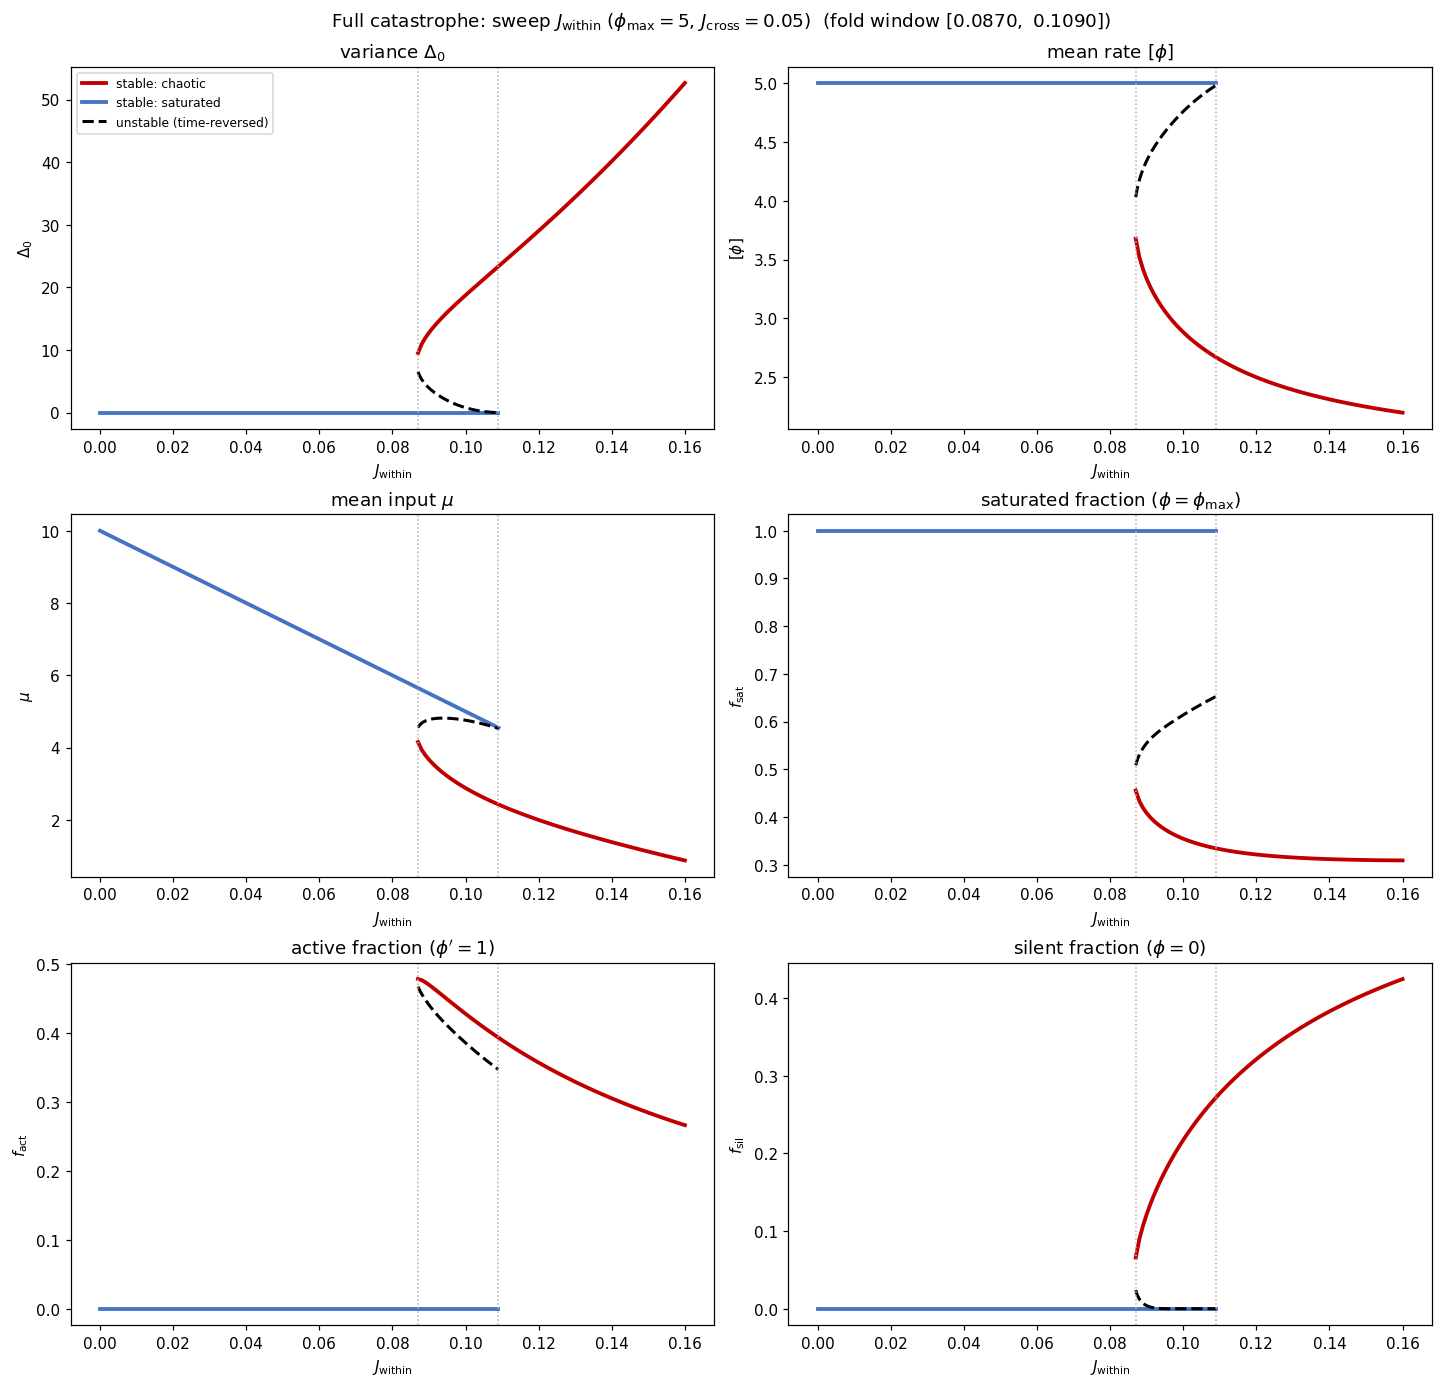

In [49]:
# ---- full catastrophe picture for the J_within sweep (chaos is BORN as J_within grows) ----
res_Jwithin = catastrophe_analysis(
    sweep=lambda v: {"areas[0].J_exc": v, "areas[1].J_exc": v},
    base_updates={"J_cross[0,1]": 0.05, "J_cross[1,0]": 0.05},
    xvals=np.linspace(0.0, 0.16, 161),
    xlabel=r'$J_{\rm within}$',
    title=r'Full catastrophe: sweep $J_{\rm within}$ ($\phi_{\max}=5$, $J_{\rm cross}=0.05$)',
    fname="DMFT_catastrophe_full_picture_Jwithin.png")

---
**Summary.** Bounded activation turns the chaos transition **subcritical**: increasing the
cross-coupling $J_{\rm cross}$ saturates the neurons, collapses the activation variance, and
destroys the chaotic state in a **fold catastrophe** with a bistable (chaotic / saturated)
window $J_{\rm cross}\in[0.048,0.056]$. The nullcline analysis exhibits the fold as
intersections appearing and merging; the $\phi'$-decomposition identifies its mechanism as
population-wide saturation; and time-reversed dynamics recovers the unstable branch that closes
the $S$-curve.